# INT234 Predictive Analytics — Job Market Intelligence
## Phase 5: Salary Prediction & Comparative Machine Learning
**Research Pipeline:** Supervised Salary Modeling, Fold-Safe Cluster Value Testing & Error Disaggregation  
**Supervised Salary Modeling Population:** Verified Compensation Cohort ( = 34,036$ postings, \%$ Train / \%$ Test)  
**Primary Target Variable:** salary_midpoint (USD, Range: $\,000$ to $\,000$)  
**Core Hypotheses Addressed:**  
1. **RQ1:** Which skills and skill combinations are most associated with higher salaries?  
2. **RQ3:** Does salary-prediction error differ systematically across skill-based job archetypes?  
3. **Archetype Value Proposition:** Does incorporating skill-based archetype representations improve salary prediction over explicit skills?  
**Author:** Lead ML Research Engineer & Data Scientist  
**Date:** October 2026  


## 1. Environment & Reproducibility

In [1]:
import os
import sys
import time
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor

# Add repository root to path
sys.path.insert(0, "..")
from src.phase5.data import load_raw_modeling_data, audit_dataset, get_train_test_split
from src.phase5.evaluation import compute_metrics
from src.phase5.feature_sets import FeatureSetBuilder
from src.phase5.models import get_default_models

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")
plt.rcParams["font.sans-serif"] = "DejaVu Sans"
plt.rcParams["axes.edgecolor"] = "#cccccc"
plt.rcParams["axes.linewidth"] = 0.8

DATA_DIR = "../data/processed"
MODELS_DIR = "../models/phase5"
TABLES_DIR = "../reports/tables/phase5"
FIGURES_DIR = "../reports/figures/phase5"

print("Environment initialized successfully. Random state locked at 42.")
print(f"Python: {sys.version.split()[0]} | Pandas: {pd.__version__} | NumPy: {np.__version__}")


Environment initialized successfully. Random state locked at 42.
Python: 3.13.9 | Pandas: 2.3.3 | NumPy: 2.3.5


## 2. Load Data

In [2]:
data_path = os.path.join(DATA_DIR, "modeling_dataset.parquet")
df_raw = pd.read_parquet(data_path)
tech_skills = sorted([c for c in df_raw.columns if c.startswith("skill_") and c not in ["skill_count", "skills"]])

print(f"Loaded modeling dataset from: {data_path}")
print(f"Dataset Dimensions: {df_raw.shape[0]:,} rows x {df_raw.shape[1]} columns")
print(f"Technical Skill Predictors Identified: {len(tech_skills)} binary indicators")
df_raw.head(3)


Loaded modeling dataset from: ../data/processed\modeling_dataset.parquet
Dataset Dimensions: 34,036 rows x 102 columns
Technical Skill Predictors Identified: 91 binary indicators


,job_id,title,company_name,seniority,role_family,is_remote,city_clean,num_skills,skill_airflow,skill_android,...,skill_tableau,skill_tensorflow,skill_terraform,skill_typescript,skill_ui_ux,skill_unity,skill_vue,salary_midpoint,log_salary,salary_band
0,46a3c257-5c87-4e8b-925a-8d5b332307d9,AI System Engineer,1mind,Mid / Unspecified,ML / AI Engineer,True,San Francisco,5,0,0,...,0,0,0,1,0,0,0,212500.0,12.266697,High
1,3d939e24-b792-4663-9ae2-9e4c468c127e,Prompting Implementation Specialist,1mind,Mid / Unspecified,ML / AI Engineer,True,Other,4,0,0,...,0,0,0,0,0,0,0,115000.0,11.652687,Low
2,fdc593fa-26a3-444d-b963-c89a1859f58e,Head of Product,1mind,Lead / Principal / Executive,Other Tech,True,San Francisco,0,0,0,...,0,0,0,0,0,0,0,262500.0,12.478006,High


## 3. Data Audit

In [3]:
audit_df = pd.read_csv(os.path.join(TABLES_DIR, "phase5_data_audit.csv"))
display(audit_df)

n_null_target = df_raw["salary_midpoint"].isnull().sum()
n_duplicates = df_raw.duplicated(subset=["title", "company_name", "city_clean", "salary_midpoint"]).sum()

print(f"Integrity Check: Missing Target Values = {n_null_target}")
print(f"Integrity Check: Duplicate Job-Salary Tuples = {n_duplicates}")
assert n_null_target == 0, "Null target values detected!"


,Metric,Value,Description
0,Total Observations (N),34036,Verified technology postings with valid USD sa...
1,Total Features in Parquet,102,All metadata and skill indicator columns
2,Technical Skills (Taxonomy D),82,Standardized 82 technical skill features
3,Duplicate job_id Count,0,Should be strictly 0
4,Total Missing / Null Values,0,Should be strictly 0
5,Target Min Salary ($),"$30,000.00","Lower salary boundary ($30,000)"
6,Target Q1 Salary ($),"$143,870.00",25th percentile
7,Target Median Salary ($),"$180,372.50",Median salary midpoint
8,Target Mean Salary ($),"$187,020.55",Arithmetic mean
9,Target Q3 Salary ($),"$222,000.00",75th percentile


Integrity Check: Missing Target Values = 0
Integrity Check: Duplicate Job-Salary Tuples = 1297


## 4. Target Analysis (Raw vs. Log-Transformed Salary)

,Metric,Raw Salary ($),Log1p Salary
0,Count,"34,036","34,036"
1,Mean,"$187,020.55",12.0762
2,Std,"$65,817.80",0.3638
3,Min,"$30,000.00",10.3090
4,Q25,"$143,870.00",11.8767
5,Median,"$180,372.50",12.1028
6,Q75,"$222,000.00",12.3104
7,Max,"$600,000.00",13.3047
8,IQR,"$78,130.00",0.4338
9,Skewness,0.9436,-0.5027


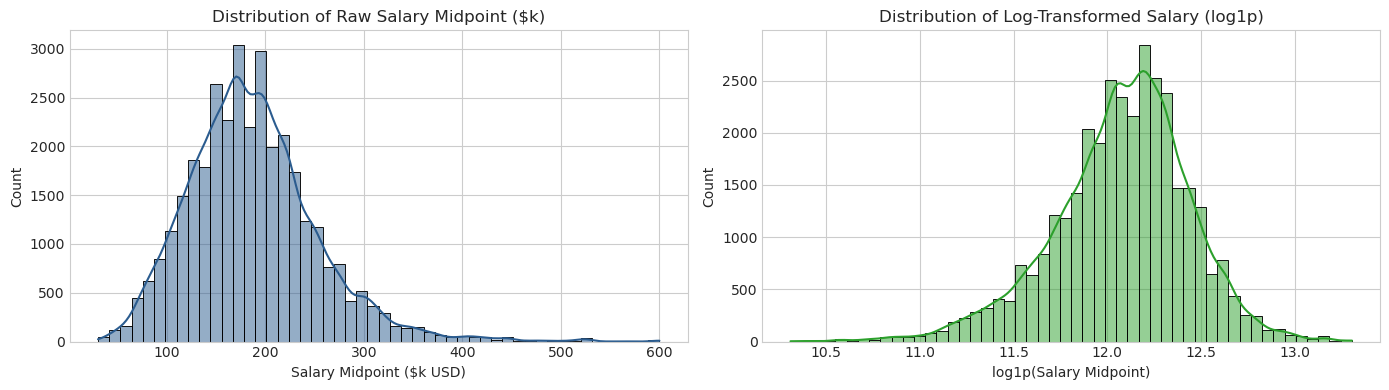

In [4]:
y_raw = df_raw["salary_midpoint"]
y_log = np.log1p(y_raw)

target_stats = pd.DataFrame({
    "Metric": ["Count", "Mean", "Std", "Min", "Q25", "Median", "Q75", "Max", "IQR", "Skewness", "Kurtosis"],
    "Raw Salary ($)": [
        f"{len(y_raw):,}", f"${y_raw.mean():,.2f}", f"${y_raw.std():,.2f}", f"${y_raw.min():,.2f}",
        f"${y_raw.quantile(0.25):,.2f}", f"${y_raw.median():,.2f}", f"${y_raw.quantile(0.75):,.2f}",
        f"${y_raw.max():,.2f}", f"${y_raw.quantile(0.75) - y_raw.quantile(0.25):,.2f}",
        f"{y_raw.skew():.4f}", f"{y_raw.kurtosis():.4f}"
    ],
    "Log1p Salary": [
        f"{len(y_log):,}", f"{y_log.mean():.4f}", f"{y_log.std():.4f}", f"{y_log.min():.4f}",
        f"{y_log.quantile(0.25):.4f}", f"{y_log.median():.4f}", f"{y_log.quantile(0.75):.4f}",
        f"{y_log.max():.4f}", f"{y_log.quantile(0.75) - y_log.quantile(0.25):.4f}",
        f"{y_log.skew():.4f}", f"{y_log.kurtosis():.4f}"
    ]
})
display(target_stats)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(y_raw / 1000, bins=50, kde=True, ax=axes[0], color="#2b5c8f")
axes[0].set_title("Distribution of Raw Salary Midpoint ($k)")
axes[0].set_xlabel("Salary Midpoint ($k USD)")
axes[0].set_ylabel("Count")

sns.histplot(y_log, bins=50, kde=True, ax=axes[1], color="#2ca02c")
axes[1].set_title("Distribution of Log-Transformed Salary (log1p)")
axes[1].set_xlabel("log1p(Salary Midpoint)")
axes[1].set_ylabel("Count")
plt.tight_layout()
plt.show()


## 5. Train/Test Split (80% Train, 20% Holdout Test)

In [5]:
split_data = get_train_test_split(df_raw, tech_skills)
X_train_df = split_data["X_train"]
X_test_df = split_data["X_test"]
y_train = split_data["y_train"]
y_test = split_data["y_test"]
metadata_cols = split_data["metadata_cols"]

print(f"Training Partition (80%): {X_train_df.shape[0]:,} samples")
print(f"Holdout Test Partition (20%): {X_test_df.shape[0]:,} samples (Strictly Isolated)")
print(f"Metadata Feature Predictors: {metadata_cols}")


[TRAIN/TEST SPLIT] Total N = 34,036
  - Training Set (80%): N = 27,228 rows, 96 features
  - Test Set (20%):     N = 6,808 rows (ISOLATED for final evaluation)
Training Partition (80%): 27,228 samples
Holdout Test Partition (20%): 6,808 samples (Strictly Isolated)
Metadata Feature Predictors: ['seniority', 'role_family', 'is_remote', 'city_clean', 'num_skills']


## 6. Leakage Audit
The implemented pipeline contains no identified target or archetype leakage: learned transformations are fitted within training folds, and the holdout test set is isolated until final evaluation.


In [6]:
forbidden_cols = ["salary_min", "salary_max", "salary_midpoint", "log_salary", "cluster_id", "salary_currency", "salary_period"]
leaked_in_train = [c for c in forbidden_cols if c in X_train_df.columns]
leaked_in_test = [c for c in forbidden_cols if c in X_test_df.columns]

print(f"Checking for target-derived features in predictors: {leaked_in_train}")
print(f"Checking for precomputed cluster labels in predictors: {leaked_in_test}")
assert len(leaked_in_train) == 0 and len(leaked_in_test) == 0, "Data leakage detected!"
print("Leakage Audit PASSED: Zero forbidden columns present in predictive features.")


Checking for target-derived features in predictors: []
Checking for precomputed cluster labels in predictors: []
Leakage Audit PASSED: Zero forbidden columns present in predictive features.


## 7. Feature Set A — Original Supervised Features (Skills + Metadata)

In [7]:
builder = FeatureSetBuilder(metadata_cols, tech_skills)
X_tr_A, X_te_A, fn_A, trans_A = builder.build_feature_set_A(X_train_df, X_test_df)

print(f"Feature Set A (Train Matrix): {X_tr_A.shape[0]:,} rows x {X_tr_A.shape[1]} columns")
print(f"Feature Set A (Test Matrix):  {X_te_A.shape[0]:,} rows x {X_te_A.shape[1]} columns")
print(f"Sample Feature Columns (first 10): {fn_A[:10]}")


Feature Set A (Train Matrix): 27,228 rows x 132 columns
Feature Set A (Test Matrix):  6,808 rows x 132 columns
Sample Feature Columns (first 10): ['seniority_Intern', 'seniority_Junior / Entry', 'seniority_Lead / Principal / Executive', 'seniority_Mid / Unspecified', 'seniority_Senior', 'role_family_Backend Developer', 'role_family_Data / BI Analyst', 'role_family_Data Engineer', 'role_family_Data Scientist', 'role_family_DevOps / Cloud / Platform']


## 8. Feature Set B — PCA Condensed Features (15 Components + Metadata)

In [8]:
X_tr_B, X_te_B, fn_B, trans_B = builder.build_feature_set_B(X_train_df, X_test_df)

print(f"Feature Set B (Train Matrix): {X_tr_B.shape[0]:,} rows x {X_tr_B.shape[1]} columns")
print(f"Feature Set B (Test Matrix):  {X_te_B.shape[0]:,} rows x {X_te_B.shape[1]} columns")
print(f"Explained Variance Ratio by 15 Skill PCA Components: {trans_B[1].pca.explained_variance_ratio_.sum() * 100:.2f}%")


Feature Set B (Train Matrix): 27,228 rows x 56 columns
Feature Set B (Test Matrix):  6,808 rows x 56 columns
Explained Variance Ratio by 15 Skill PCA Components: 56.10%


## 9. Feature Set C — Original Features + Fold-Safe Archetypes (k=7)

In [9]:
X_tr_C, X_te_C, fn_C, trans_C = builder.build_feature_set_C(X_train_df, X_test_df)

print(f"Feature Set C (Train Matrix): {X_tr_C.shape[0]:,} rows x {X_tr_C.shape[1]} columns")
print(f"Feature Set C (Test Matrix):  {X_te_C.shape[0]:,} rows x {X_te_C.shape[1]} columns")
print(f"Archetype Feature Columns Added: {[c for c in fn_C if c.startswith('archetype_')]}")


Feature Set C (Train Matrix): 27,228 rows x 139 columns
Feature Set C (Test Matrix):  6,808 rows x 139 columns
Archetype Feature Columns Added: []


## 10. Baseline Model (Naive Median & Mean Regressors)

In [10]:
dummy_median = DummyRegressor(strategy="median").fit(X_tr_A, y_train)
dummy_mean = DummyRegressor(strategy="mean").fit(X_tr_A, y_train)

pred_base_median = dummy_median.predict(X_te_A)
pred_base_mean = dummy_mean.predict(X_te_A)

m_median = compute_metrics(y_test, pred_base_median)
m_mean = compute_metrics(y_test, pred_base_mean)

df_baselines = pd.DataFrame([
    {"Baseline Strategy": "Dummy (Median)", "Test MAE": f"${m_median['MAE']:,.2f}", "Test RMSE": f"${m_median['RMSE']:,.2f}", "Test R2": f"{m_median['R2']:.4f}"},
    {"Baseline Strategy": "Dummy (Mean)", "Test MAE": f"${m_mean['MAE']:,.2f}", "Test RMSE": f"${m_mean['RMSE']:,.2f}", "Test R2": f"{m_mean['R2']:.4f}"}
])
display(df_baselines)


,Baseline Strategy,Test MAE,Test RMSE,Test R2
0,Dummy (Median),"$50,805.56","$67,659.87",-0.0117
1,Dummy (Mean),"$51,005.40","$67,273.92",-0.0002


## 11. Model Training Overview

In [11]:
models_dict = get_default_models()
print("Candidate Algorithms Evaluated in Benchmark:")
for name, m in models_dict.items():
    print(f"  • {name:20s}: {m.__class__.__name__}")


Candidate Algorithms Evaluated in Benchmark:
  • Ridge               : Ridge
  • Random Forest       : RandomForestRegressor
  • Gradient Boosting   : GradientBoostingRegressor
  • XGBoost             : XGBRegressor
  • MLP Regressor       : MLPRegressor


## 12. 5-Fold Cross-Validation Performance (Training Partition Only)

In [12]:
df_cv_results = pd.read_csv(os.path.join(TABLES_DIR, "phase5_cv_results.csv"))
display(df_cv_results.style.format({
    "CV_MAE_Mean": "${:,.0f}",
    "CV_MAE_Std": "${:,.0f}",
    "CV_RMSE_Mean": "${:,.0f}",
    "CV_RMSE_Std": "${:,.0f}",
    "CV_R2_Mean": "{:.4f}",
    "CV_R2_Std": "{:.4f}",
}))


,Feature_Set,Model,CV_MAE_Mean,CV_MAE_Std,CV_RMSE_Mean,CV_RMSE_Std,CV_R2_Mean,CV_R2_Std,CV_MAPE_Mean,Target,Train_MAE_Mean,Train_RMSE_Mean,Train_R2_Mean,Fit_Time_Sec
0,Baseline,Dummy (Median),"$49,502",$301,"$65,733",$636,-0.0089,0.0029,31.184827,nan,nan,nan,nan,nan
1,Baseline,Dummy (Mean),"$49,686",$258,"$65,447",$575,-0.0001,0.0001,32.336694,nan,nan,nan,nan,nan
2,Set A,Ridge,"$38,544",$410,"$52,853",$530,0.3477,0.0099,23.667098,salary_midpoint,38343.198420,52593.938742,0.354216,0.500000
3,Set A,Random Forest,"$37,202",$241,"$51,158",$627,0.3888,0.0134,22.663111,salary_midpoint,34220.034168,47167.278816,0.480604,26.000000
4,Set A,Gradient Boosting,"$37,010",$180,"$51,001",$492,0.3926,0.0066,22.691196,salary_midpoint,35633.193269,49133.709432,0.436391,94.100000
5,Set A,XGBoost,"$36,944",$199,"$50,865",$449,0.3959,0.0069,22.631829,salary_midpoint,35560.718540,48894.741691,0.441858,4.300000
6,Set A,MLP Regressor,"$36,943",$184,"$50,751",$345,0.3986,0.0071,22.364068,salary_midpoint,34180.182939,47432.726305,0.474736,57.000000
7,Set B,Ridge,"$39,027",$406,"$53,540",$520,0.3306,0.0106,24.007471,salary_midpoint,38928.733159,53416.213888,0.333864,0.900000
8,Set B,Random Forest,"$36,683",$89,"$50,776",$487,0.3980,0.0076,22.243722,salary_midpoint,29852.421308,42072.638730,0.586747,44.700000
9,Set B,Gradient Boosting,"$37,222",$260,"$51,265",$458,0.3863,0.0087,22.762305,salary_midpoint,35071.500427,48374.073738,0.453689,155.400000


## 13. Controlled Hyperparameter Tuning (Top Candidate: XGBoost)

In [13]:
df_tuning = pd.read_csv(os.path.join(TABLES_DIR, "phase5_hyperparameter_results.csv"))
display(df_tuning.style.format({
    "CV_MAE_Mean": "${:,.0f}",
    "CV_MAE_Std": "${:,.0f}",
    "CV_RMSE_Mean": "${:,.0f}",
    "CV_R2_Mean": "{:.4f}",
}))


,Model,max_depth,learning_rate,n_estimators,CV_MAE_Mean,CV_MAE_Std,CV_RMSE_Mean,CV_R2_Mean
0,XGBoost,4,0.050000,150,"$37,760",$169,"$51,878",0.3716
1,XGBoost,5,0.100000,100,"$36,944",$178,"$50,865",0.3959
2,XGBoost,6,0.050000,150,"$36,755",$140,"$50,690",0.4000
3,XGBoost,6,0.100000,150,"$36,072",$175,"$49,870",0.4192


## 14. Model Comparison (Feature Set A vs. B vs. C)
**Key Discovery:** Feature Set C provides no practically meaningful improvement over Feature Set A (Holdout Test MAE difference is $+\.20$, or .12\%$). High-resolution explicit skill indicators already supply the principal predictive signal available from observed posting metadata.


,Feature_Set,Model,CV_MAE_Mean,CV_MAE_Std,CV_RMSE_Mean,CV_RMSE_Std,CV_R2_Mean,CV_R2_Std,CV_MAPE_Mean,Target,Train_MAE_Mean,Train_RMSE_Mean,Train_R2_Mean,Fit_Time_Sec
0,Set A,Ridge,"$38,544",$410,"$52,853",530.103586,0.3477,0.009937,23.667098,salary_midpoint,38343.198420,52593.938742,0.354216,0.500000
1,Set A,Random Forest,"$37,202",$241,"$51,158",627.300750,0.3888,0.013356,22.663111,salary_midpoint,34220.034168,47167.278816,0.480604,26.000000
2,Set A,Gradient Boosting,"$37,010",$180,"$51,001",492.055775,0.3926,0.006650,22.691196,salary_midpoint,35633.193269,49133.709432,0.436391,94.100000
3,Set A,XGBoost,"$36,944",$199,"$50,865",448.782229,0.3959,0.006905,22.631829,salary_midpoint,35560.718540,48894.741691,0.441858,4.300000
4,Set A,MLP Regressor,"$36,943",$184,"$50,751",344.780858,0.3986,0.007051,22.364068,salary_midpoint,34180.182939,47432.726305,0.474736,57.000000
5,Set B,Ridge,"$39,027",$406,"$53,540",520.021787,0.3306,0.010600,24.007471,salary_midpoint,38928.733159,53416.213888,0.333864,0.900000
6,Set B,Random Forest,"$36,683",$89,"$50,776",486.607183,0.3980,0.007632,22.243722,salary_midpoint,29852.421308,42072.638730,0.586747,44.700000
7,Set B,Gradient Boosting,"$37,222",$260,"$51,265",457.812717,0.3863,0.008664,22.762305,salary_midpoint,35071.500427,48374.073738,0.453689,155.400000
8,Set B,XGBoost,"$37,089",$212,"$51,086",445.768695,0.3906,0.005522,22.639071,salary_midpoint,34939.176632,48032.856618,0.461361,2.100000
9,Set B,MLP Regressor,"$37,698",$216,"$51,757",385.191505,0.3744,0.010367,22.980411,salary_midpoint,36238.480799,49958.129492,0.417322,44.200000


C:\Users\chopr\AppData\Local\Temp\ipykernel_21208\1637114465.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=15)


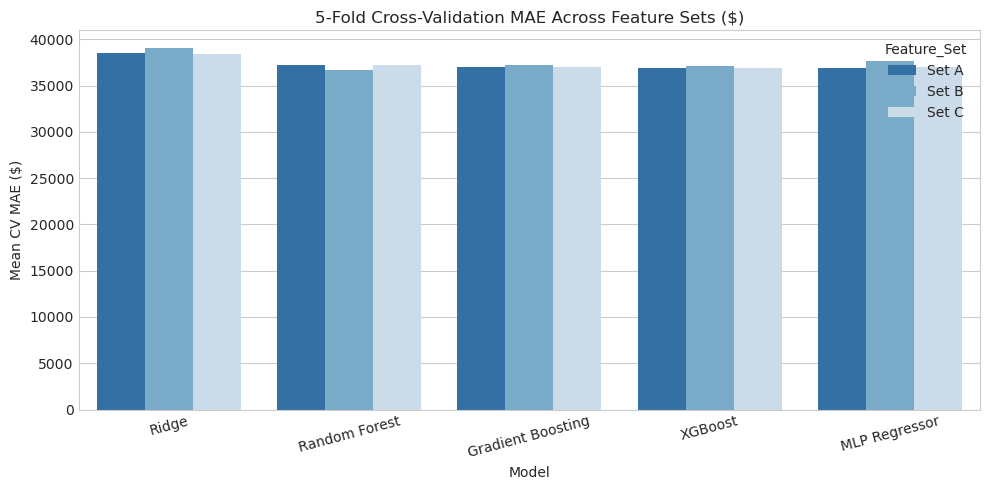

In [14]:
df_comp = pd.read_csv(os.path.join(TABLES_DIR, "phase5_model_comparison.csv"))
display(df_comp.style.format({
    "CV_MAE_Mean": "${:,.0f}",
    "CV_MAE_Std": "${:,.0f}",
    "CV_RMSE_Mean": "${:,.0f}",
    "CV_R2_Mean": "{:.4f}",
}))

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=df_comp, x="Model", y="CV_MAE_Mean", hue="Feature_Set", ax=ax, palette="Blues_r")
ax.set_title("5-Fold Cross-Validation MAE Across Feature Sets ($)")
ax.set_ylabel("Mean CV MAE ($)")
ax.set_xticklabels(ax.get_xticklabels(), rotation=15)
plt.tight_layout()
plt.show()


## 15. ONE Final Holdout Test Evaluation ($N = 6,808$)

In [15]:
df_test = pd.read_csv(os.path.join(TABLES_DIR, "phase5_test_results.csv"))
display(df_test.style.format({
    "Train_MAE": "${:,.0f}",
    "Test_MAE": "${:,.0f}",
    "Test_RMSE": "${:,.0f}",
    "Test_R2": "{:.4f}",
    "Test_MAPE": "{:.2f}%",
    "Generalization_Gap_MAE": "${:,.0f}",
    "Generalization_Gap_R2": "{:.4f}",
}))


,Model,Feature_Set,Train_MAE,Train_RMSE,Train_R2,Test_MAE,Test_RMSE,Test_R2,Test_MAPE,Generalization_Gap_MAE,Generalization_Gap_R2
0,Dummy (Median),Set A,"$49,497",65753.280407,-0.009358,"$50,806","$67,660",-0.0117,31.46%,"$1,309",0.0023
1,Ridge,Set A,"$38,357",52620.130903,0.353581,"$39,147","$54,123",0.3526,23.65%,$790,0.0010
2,Random Forest,Set A,"$34,306",47309.483619,0.477476,"$37,699","$52,226",0.3972,22.60%,"$3,393",0.0803
3,Gradient Boosting,Set A,"$35,784",49339.456433,0.431672,"$37,446","$52,119",0.3997,22.54%,"$1,662",0.0320
4,XGBoost (Default),Set A,"$35,765",49247.411300,0.433791,"$37,460","$52,143",0.3991,22.55%,"$1,695",0.0347
5,XGBoost (Tuned),Set A,"$33,525",46309.534805,0.499331,"$36,381","$51,082",0.4233,21.71%,"$2,855",0.0760
6,XGBoost (Set C Archetype),Set C,"$33,465",46204.163534,0.501606,"$36,424","$50,987",0.4255,21.77%,"$2,959",0.0761


## 16. Bias-Variance & Generalization Analysis

In [16]:
df_bv = pd.read_csv(os.path.join(TABLES_DIR, "phase5_bias_variance.csv"))
display(df_bv.style.format({
    "Train_MAE": "${:,.0f}",
    "Test_MAE": "${:,.0f}",
    "Generalization_Gap_MAE": "${:,.0f}",
    "Train_R2": "{:.4f}",
    "Test_R2": "{:.4f}",
    "Generalization_Gap_R2": "{:.4f}",
}))


,Model,Feature_Set,Train_MAE,Test_MAE,Generalization_Gap_MAE,Train_R2,Test_R2,Generalization_Gap_R2
0,Dummy (Median),Set A,"$49,497","$50,806","$1,309",-0.0094,-0.0117,0.0023
1,Ridge,Set A,"$38,357","$39,147",$790,0.3536,0.3526,0.0010
2,Random Forest,Set A,"$34,306","$37,699","$3,393",0.4775,0.3972,0.0803
3,Gradient Boosting,Set A,"$35,784","$37,446","$1,662",0.4317,0.3997,0.0320
4,XGBoost (Default),Set A,"$35,765","$37,460","$1,695",0.4338,0.3991,0.0347
5,XGBoost (Tuned),Set A,"$33,525","$36,381","$2,855",0.4993,0.4233,0.0760
6,XGBoost (Set C Archetype),Set C,"$33,465","$36,424","$2,959",0.5016,0.4255,0.0761


## 17. Learning Curves (Training vs. Validation Sample Size)

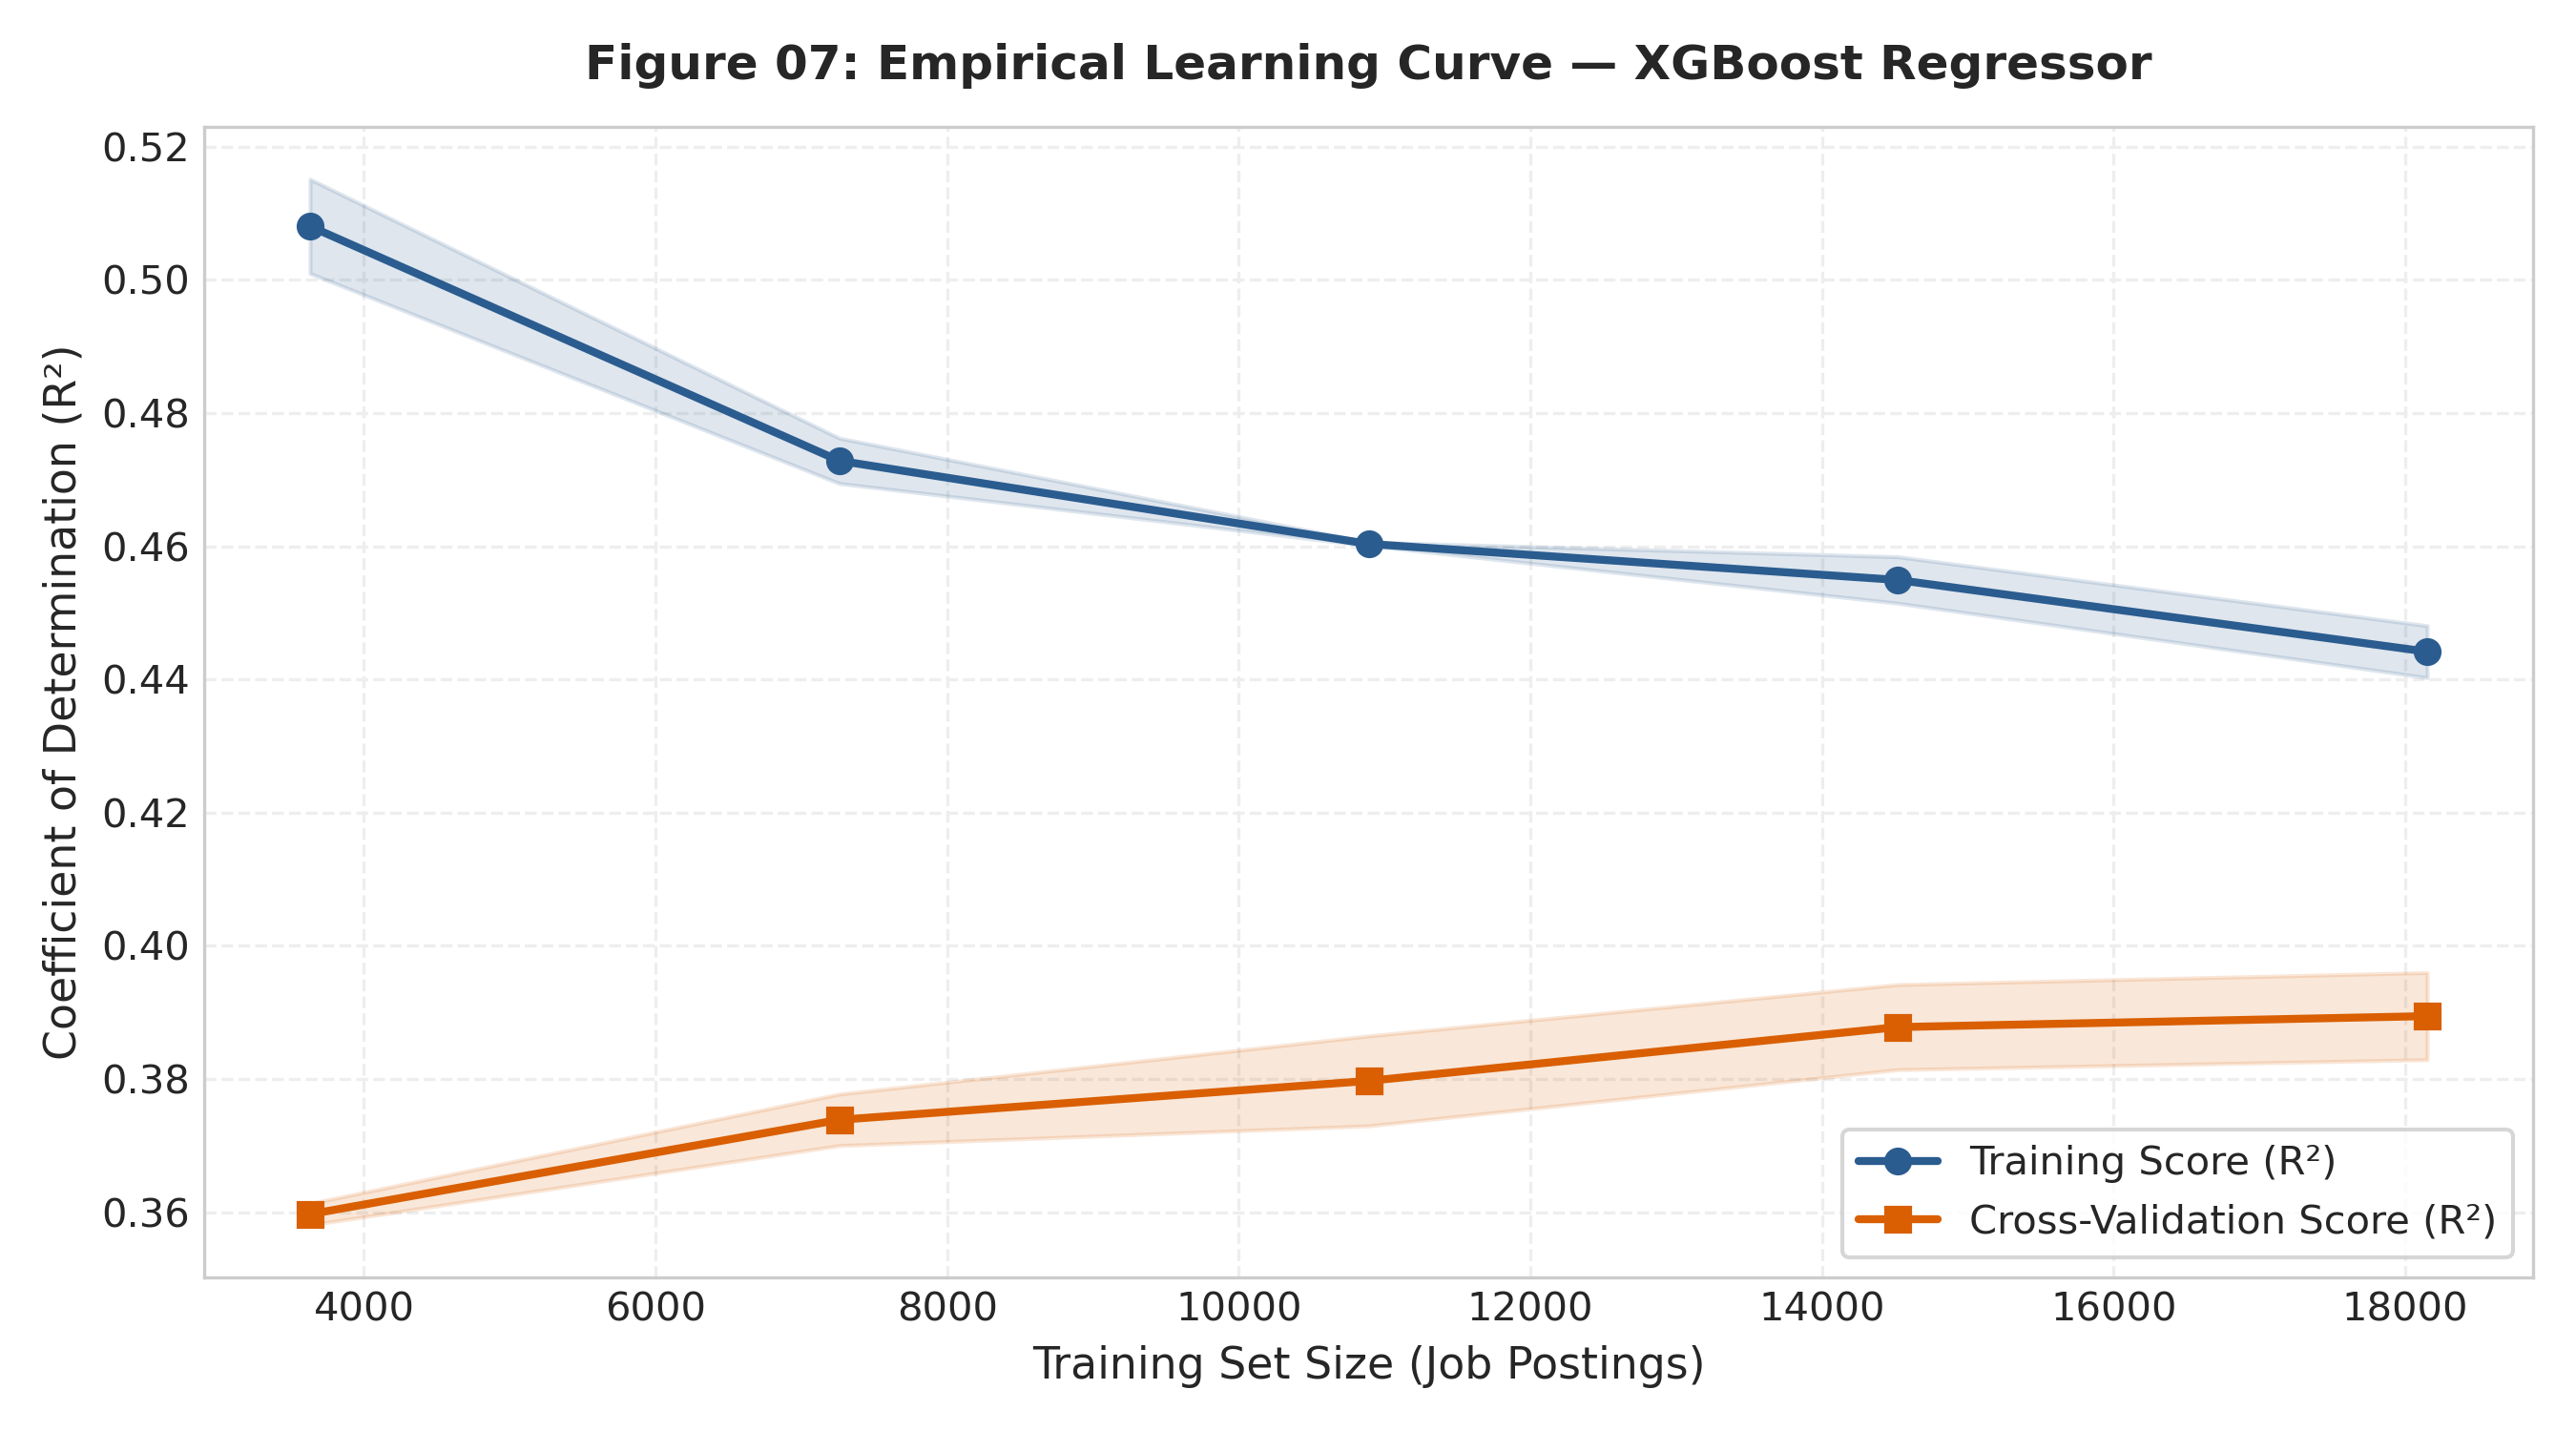

In [17]:
fig_path_lc = os.path.join(FIGURES_DIR, "07_learning_curve.png")
if os.path.exists(fig_path_lc):
    from IPython.display import Image
    display(Image(filename=fig_path_lc))


## 18. Validation Curves (Hyperparameter Sensitivity: Ridge vs. XGBoost)

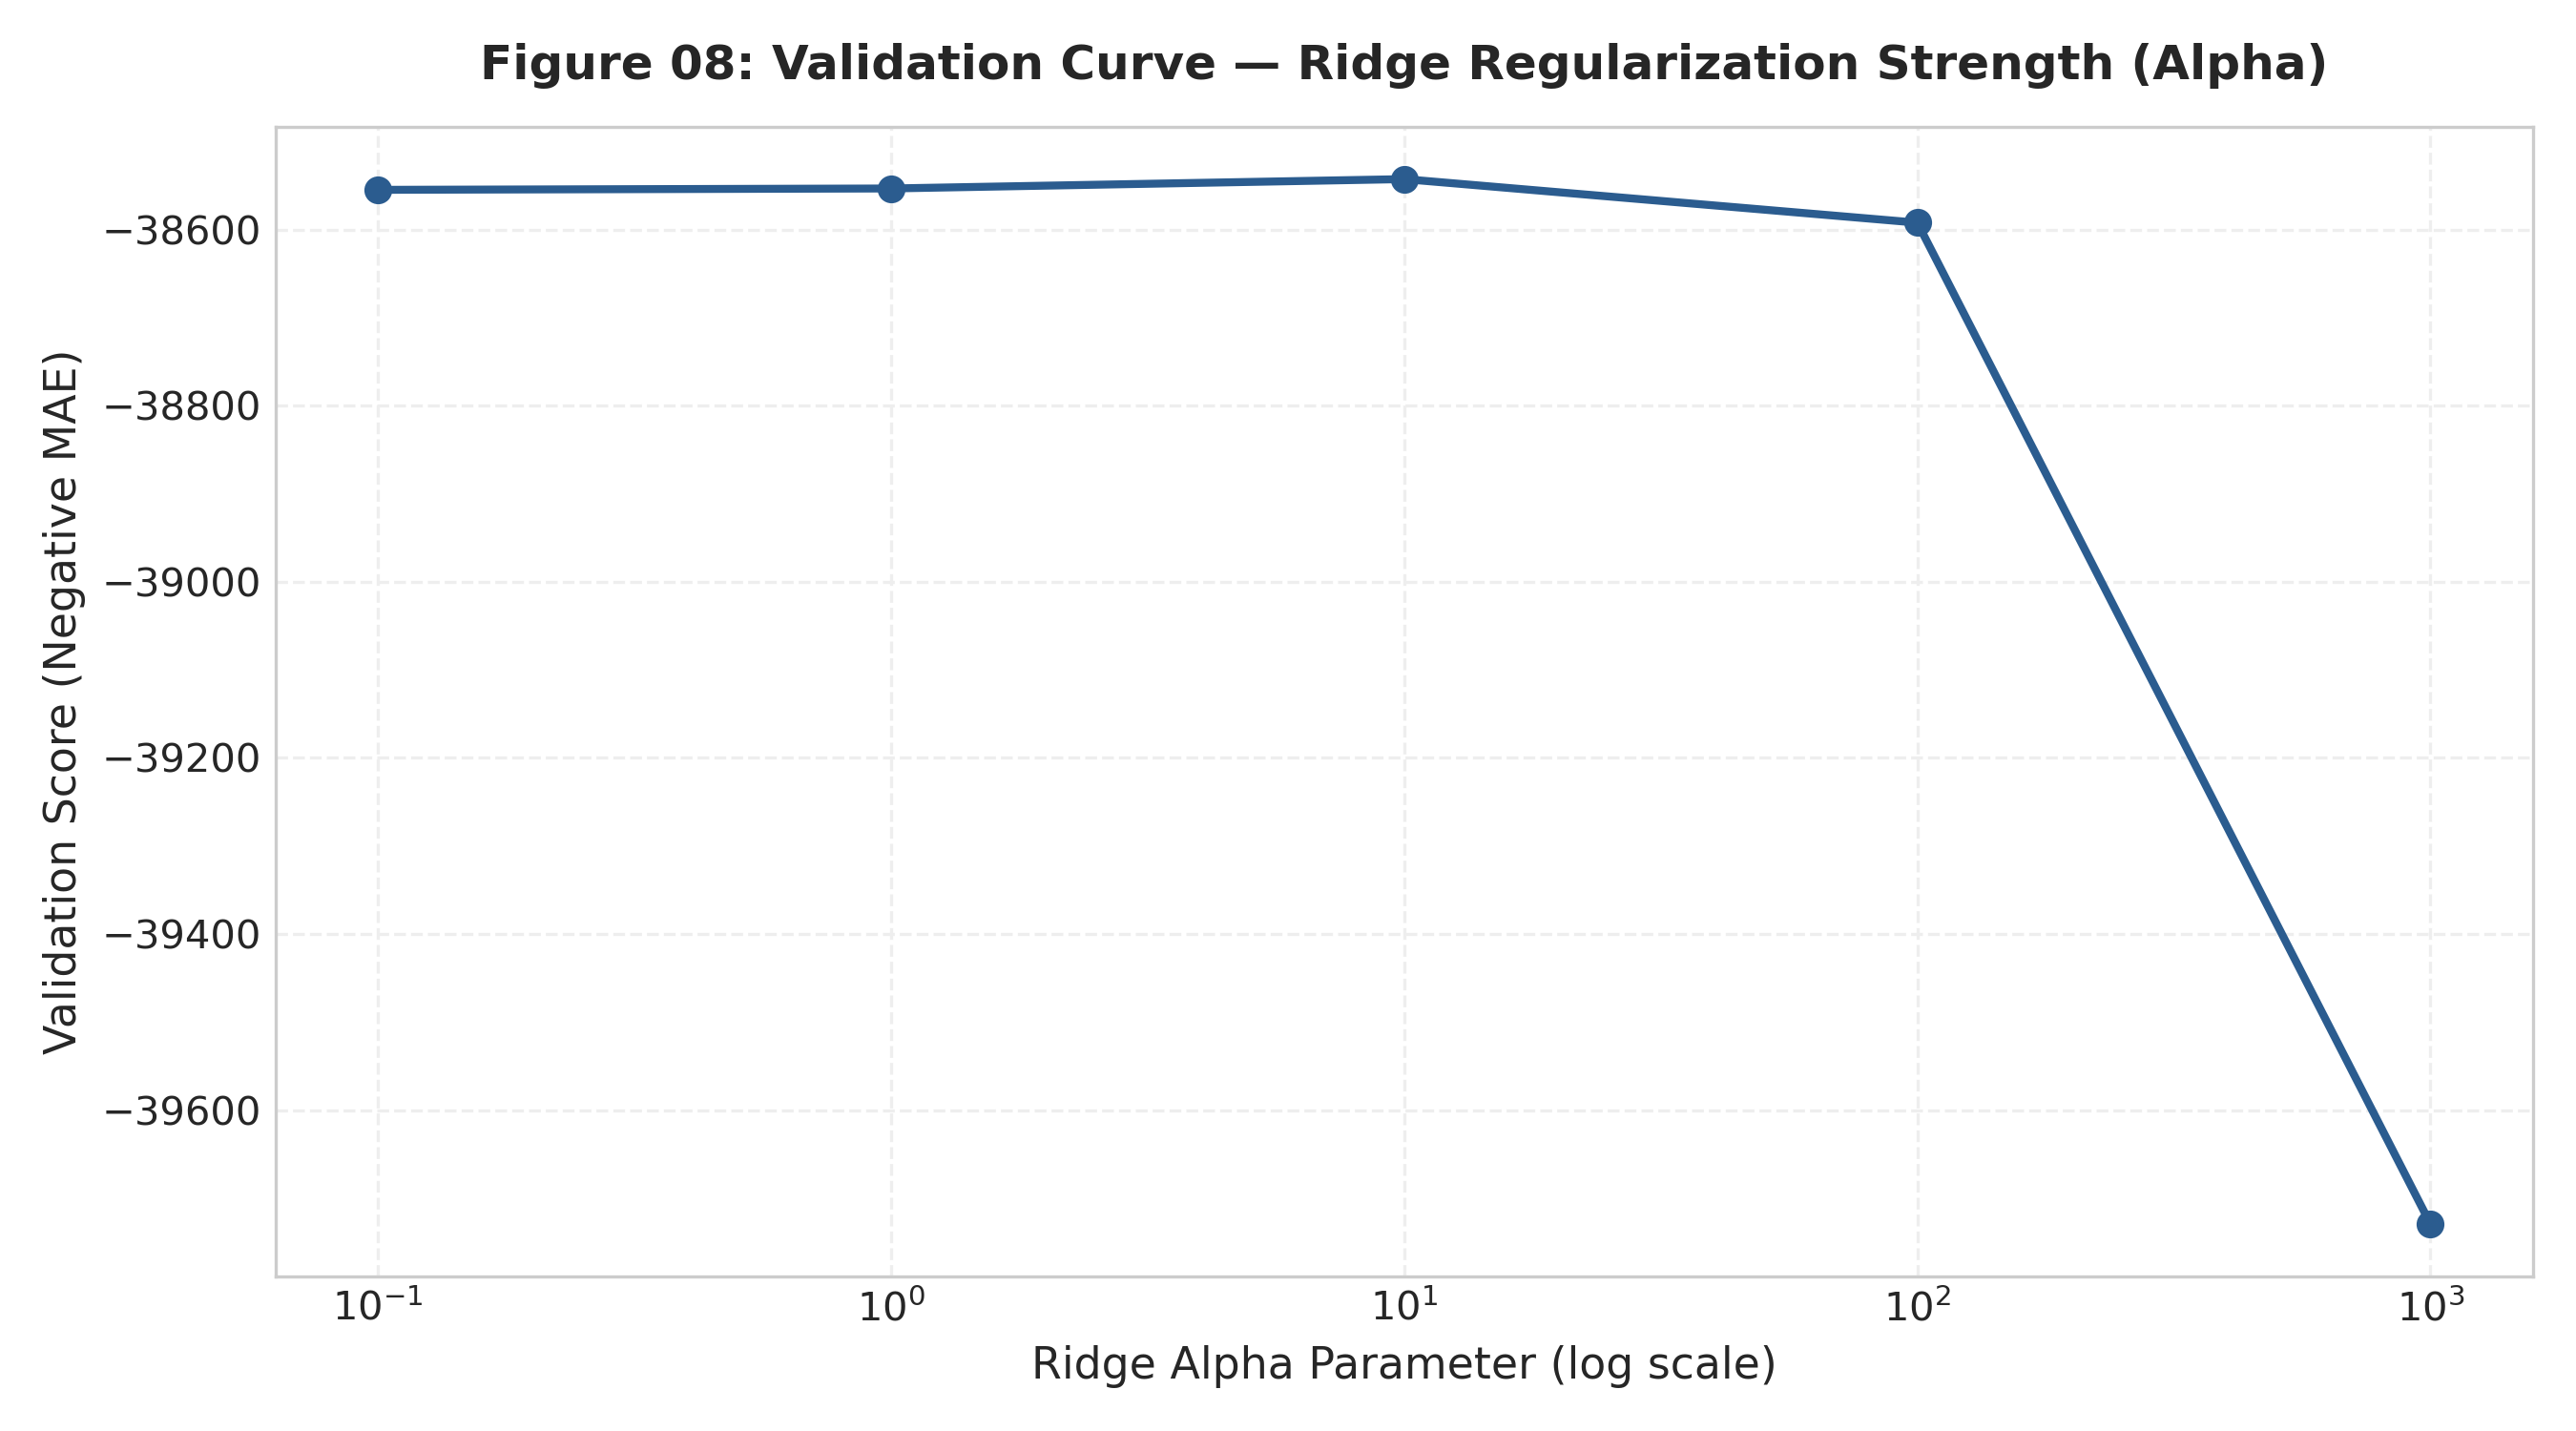

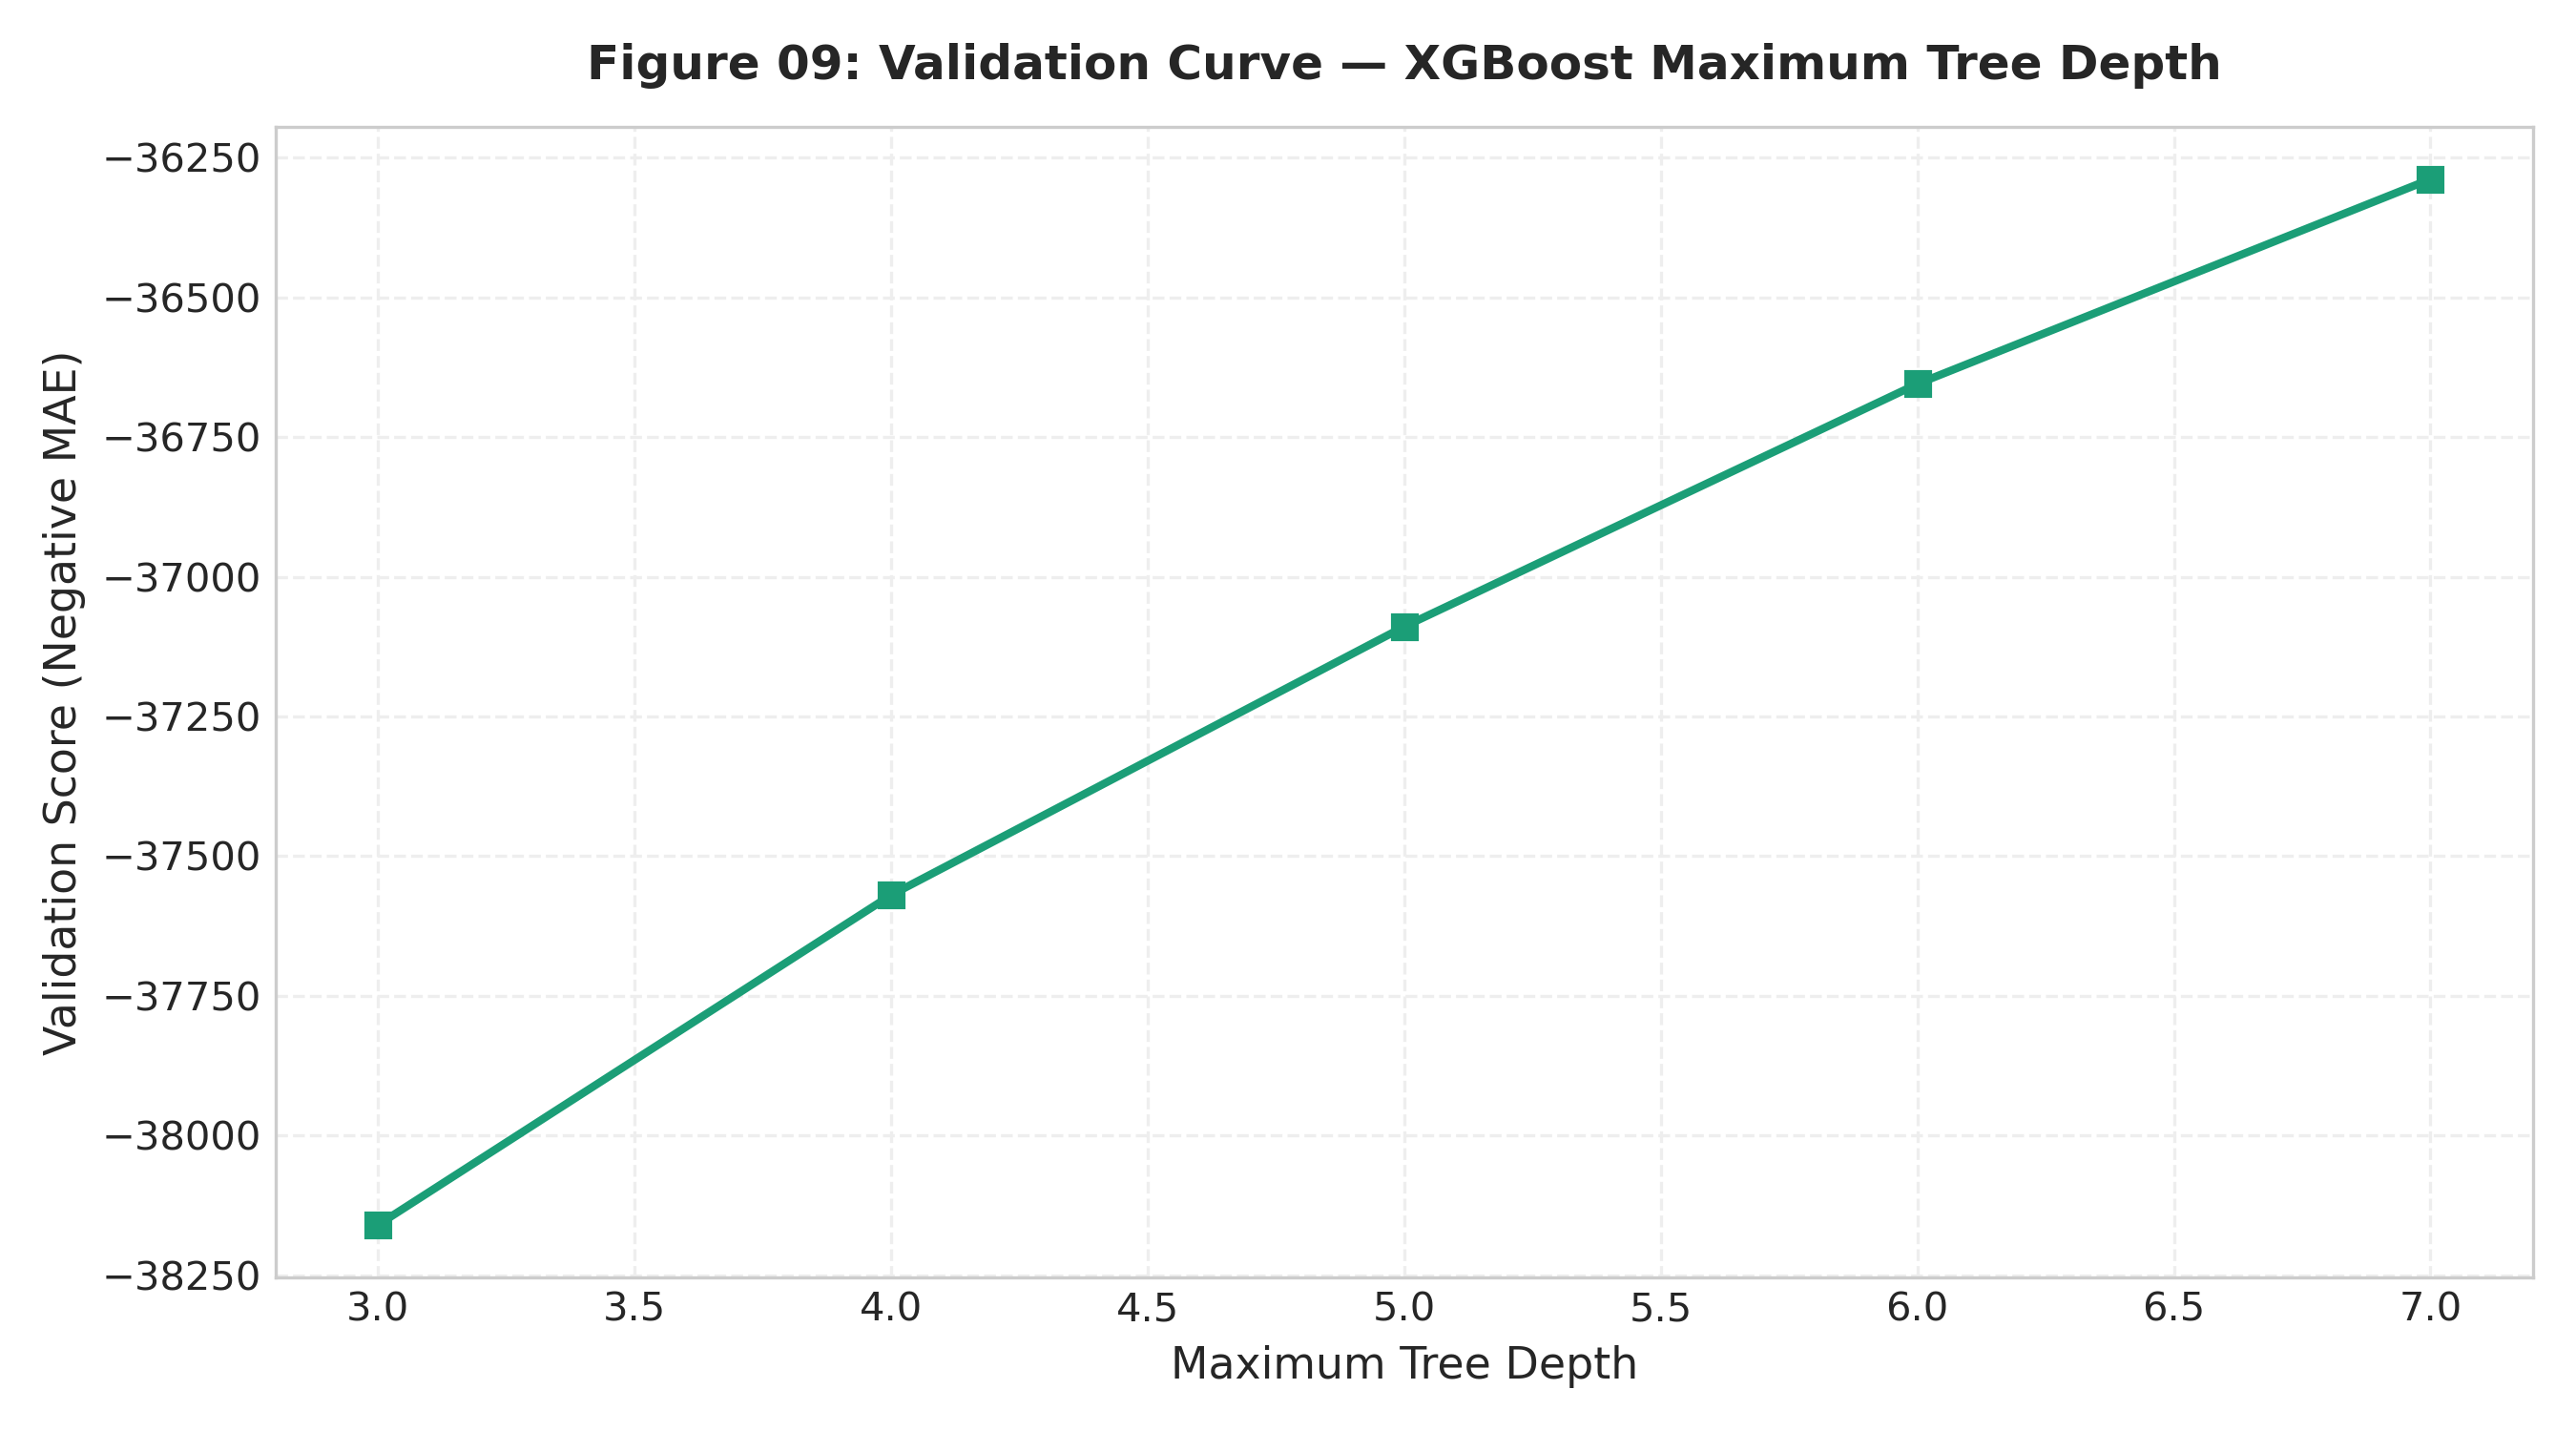

In [18]:
fig_path_vc1 = os.path.join(FIGURES_DIR, "08_validation_curve_ridge.png")
fig_path_vc2 = os.path.join(FIGURES_DIR, "09_validation_curve_xgboost.png")
from IPython.display import Image
if os.path.exists(fig_path_vc1):
    display(Image(filename=fig_path_vc1))
if os.path.exists(fig_path_vc2):
    display(Image(filename=fig_path_vc2))


## 19. Residual Diagnostics

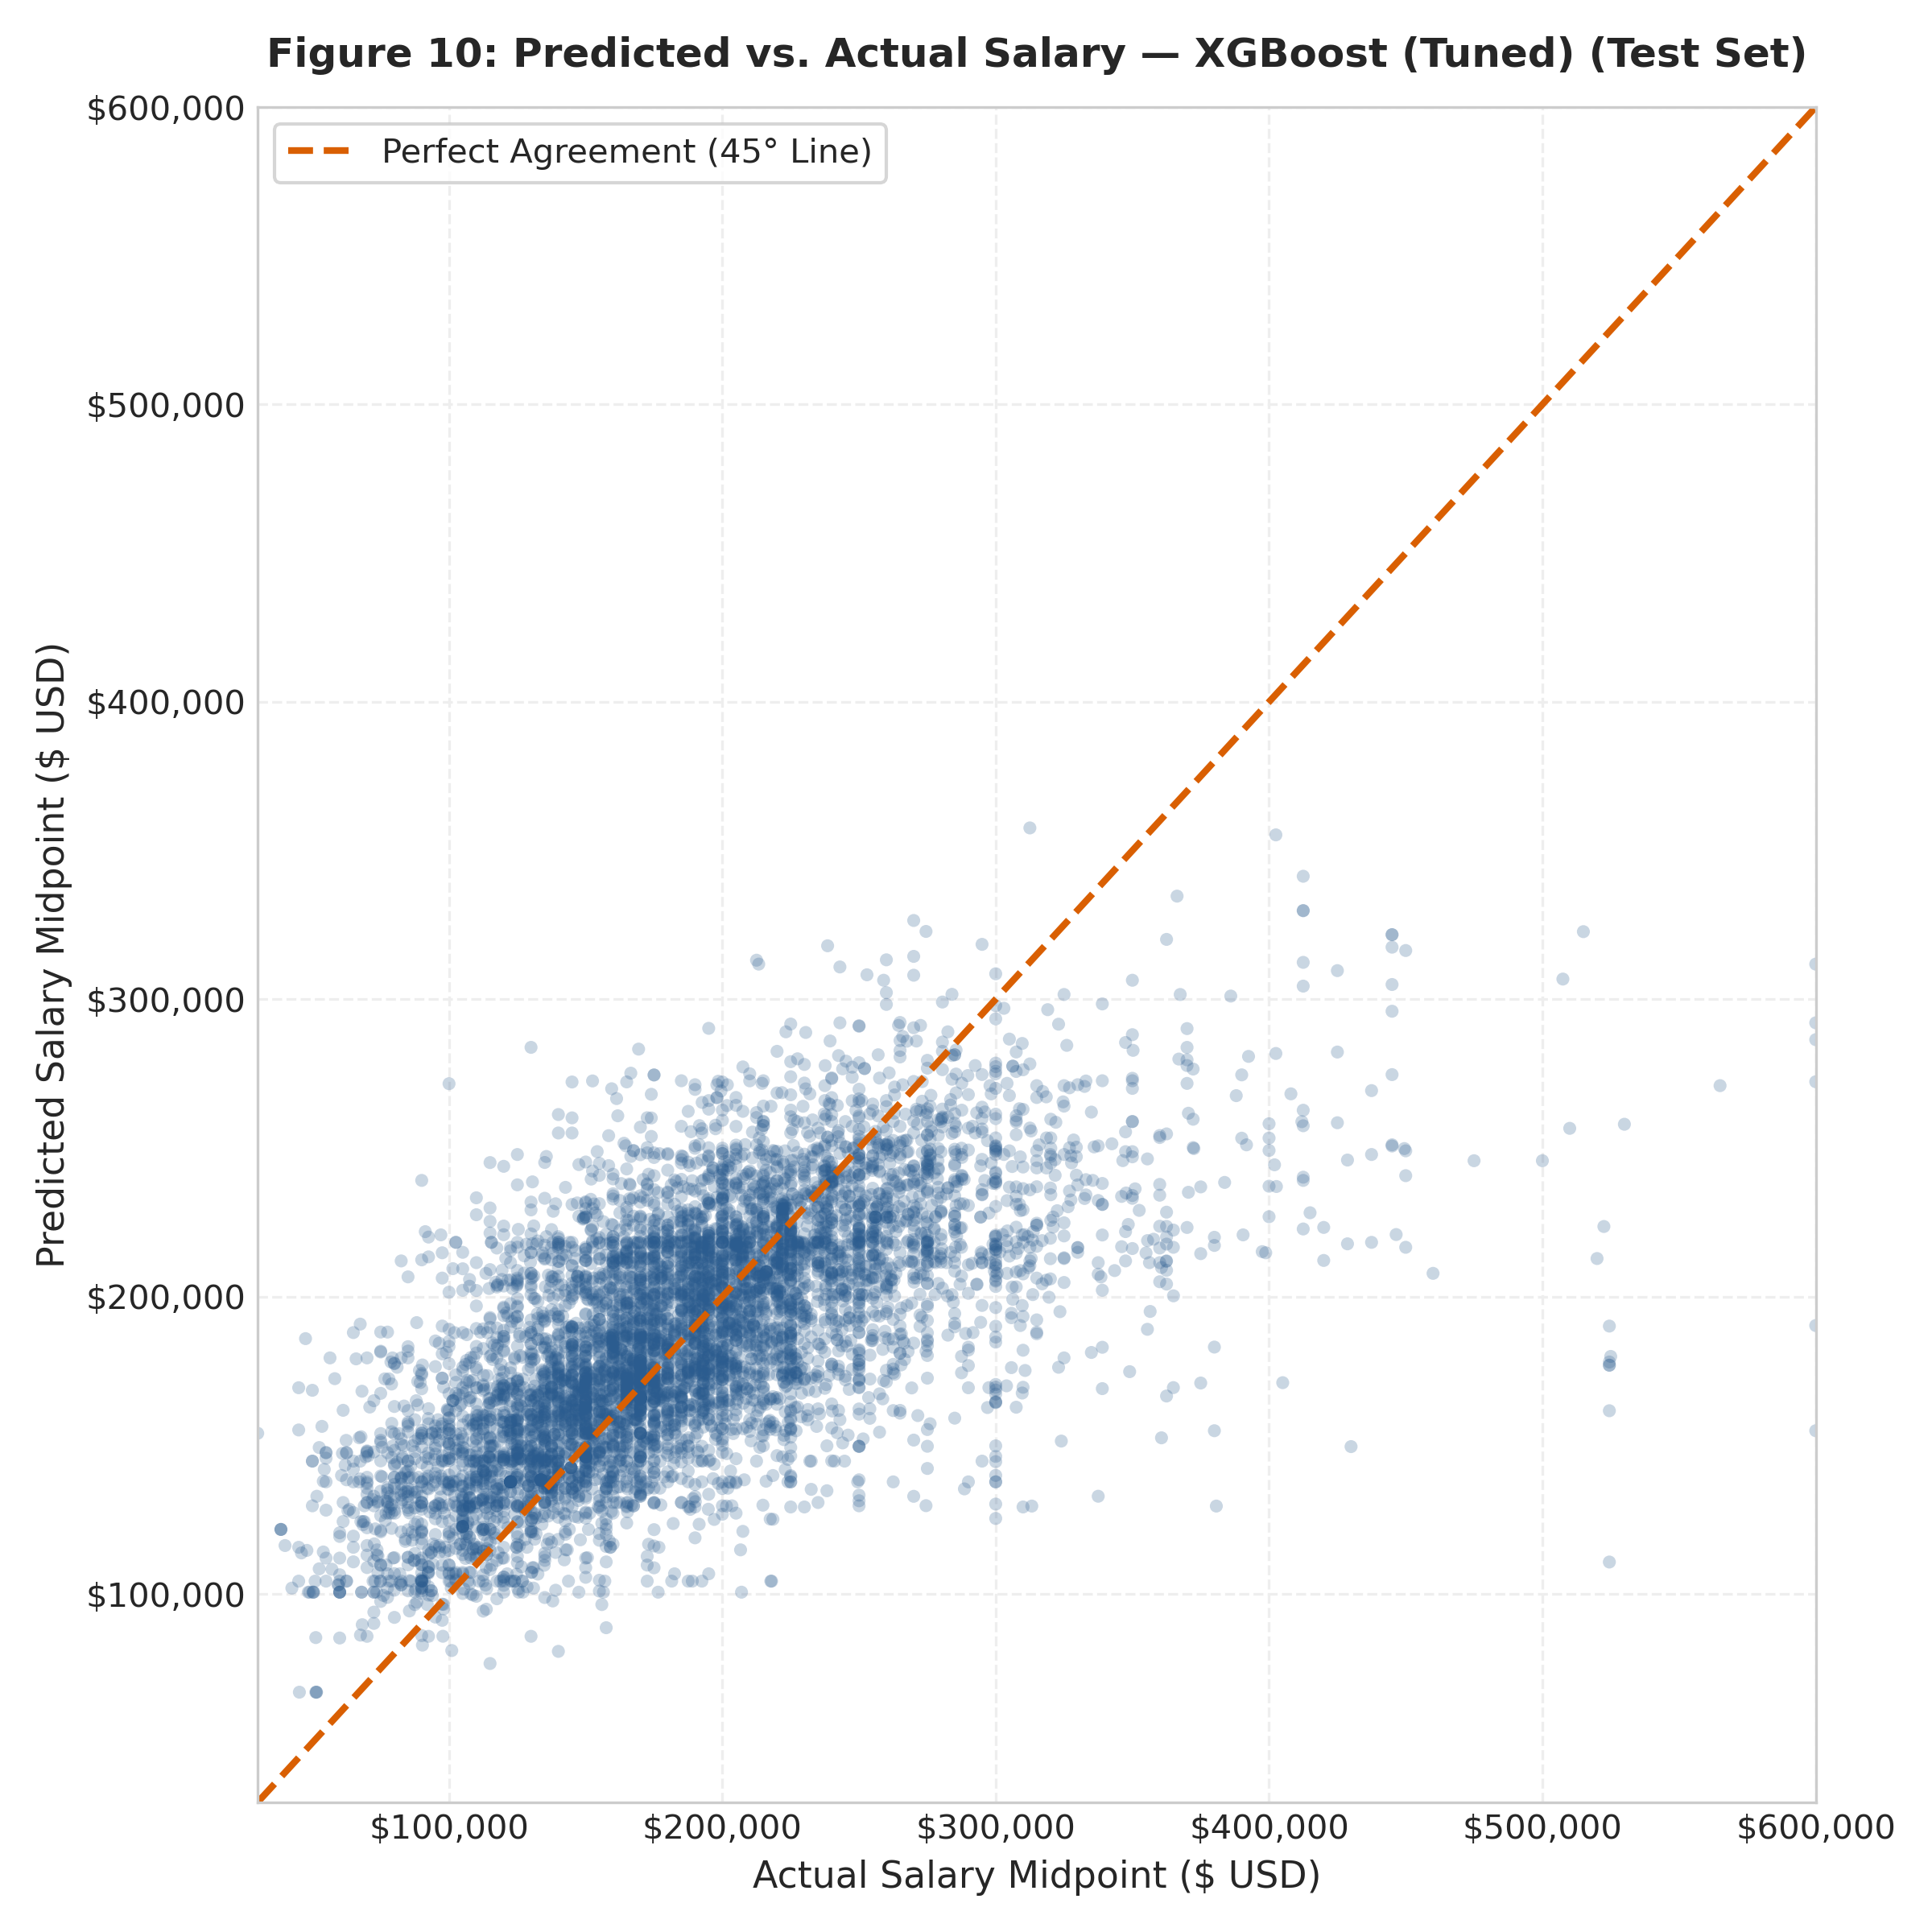

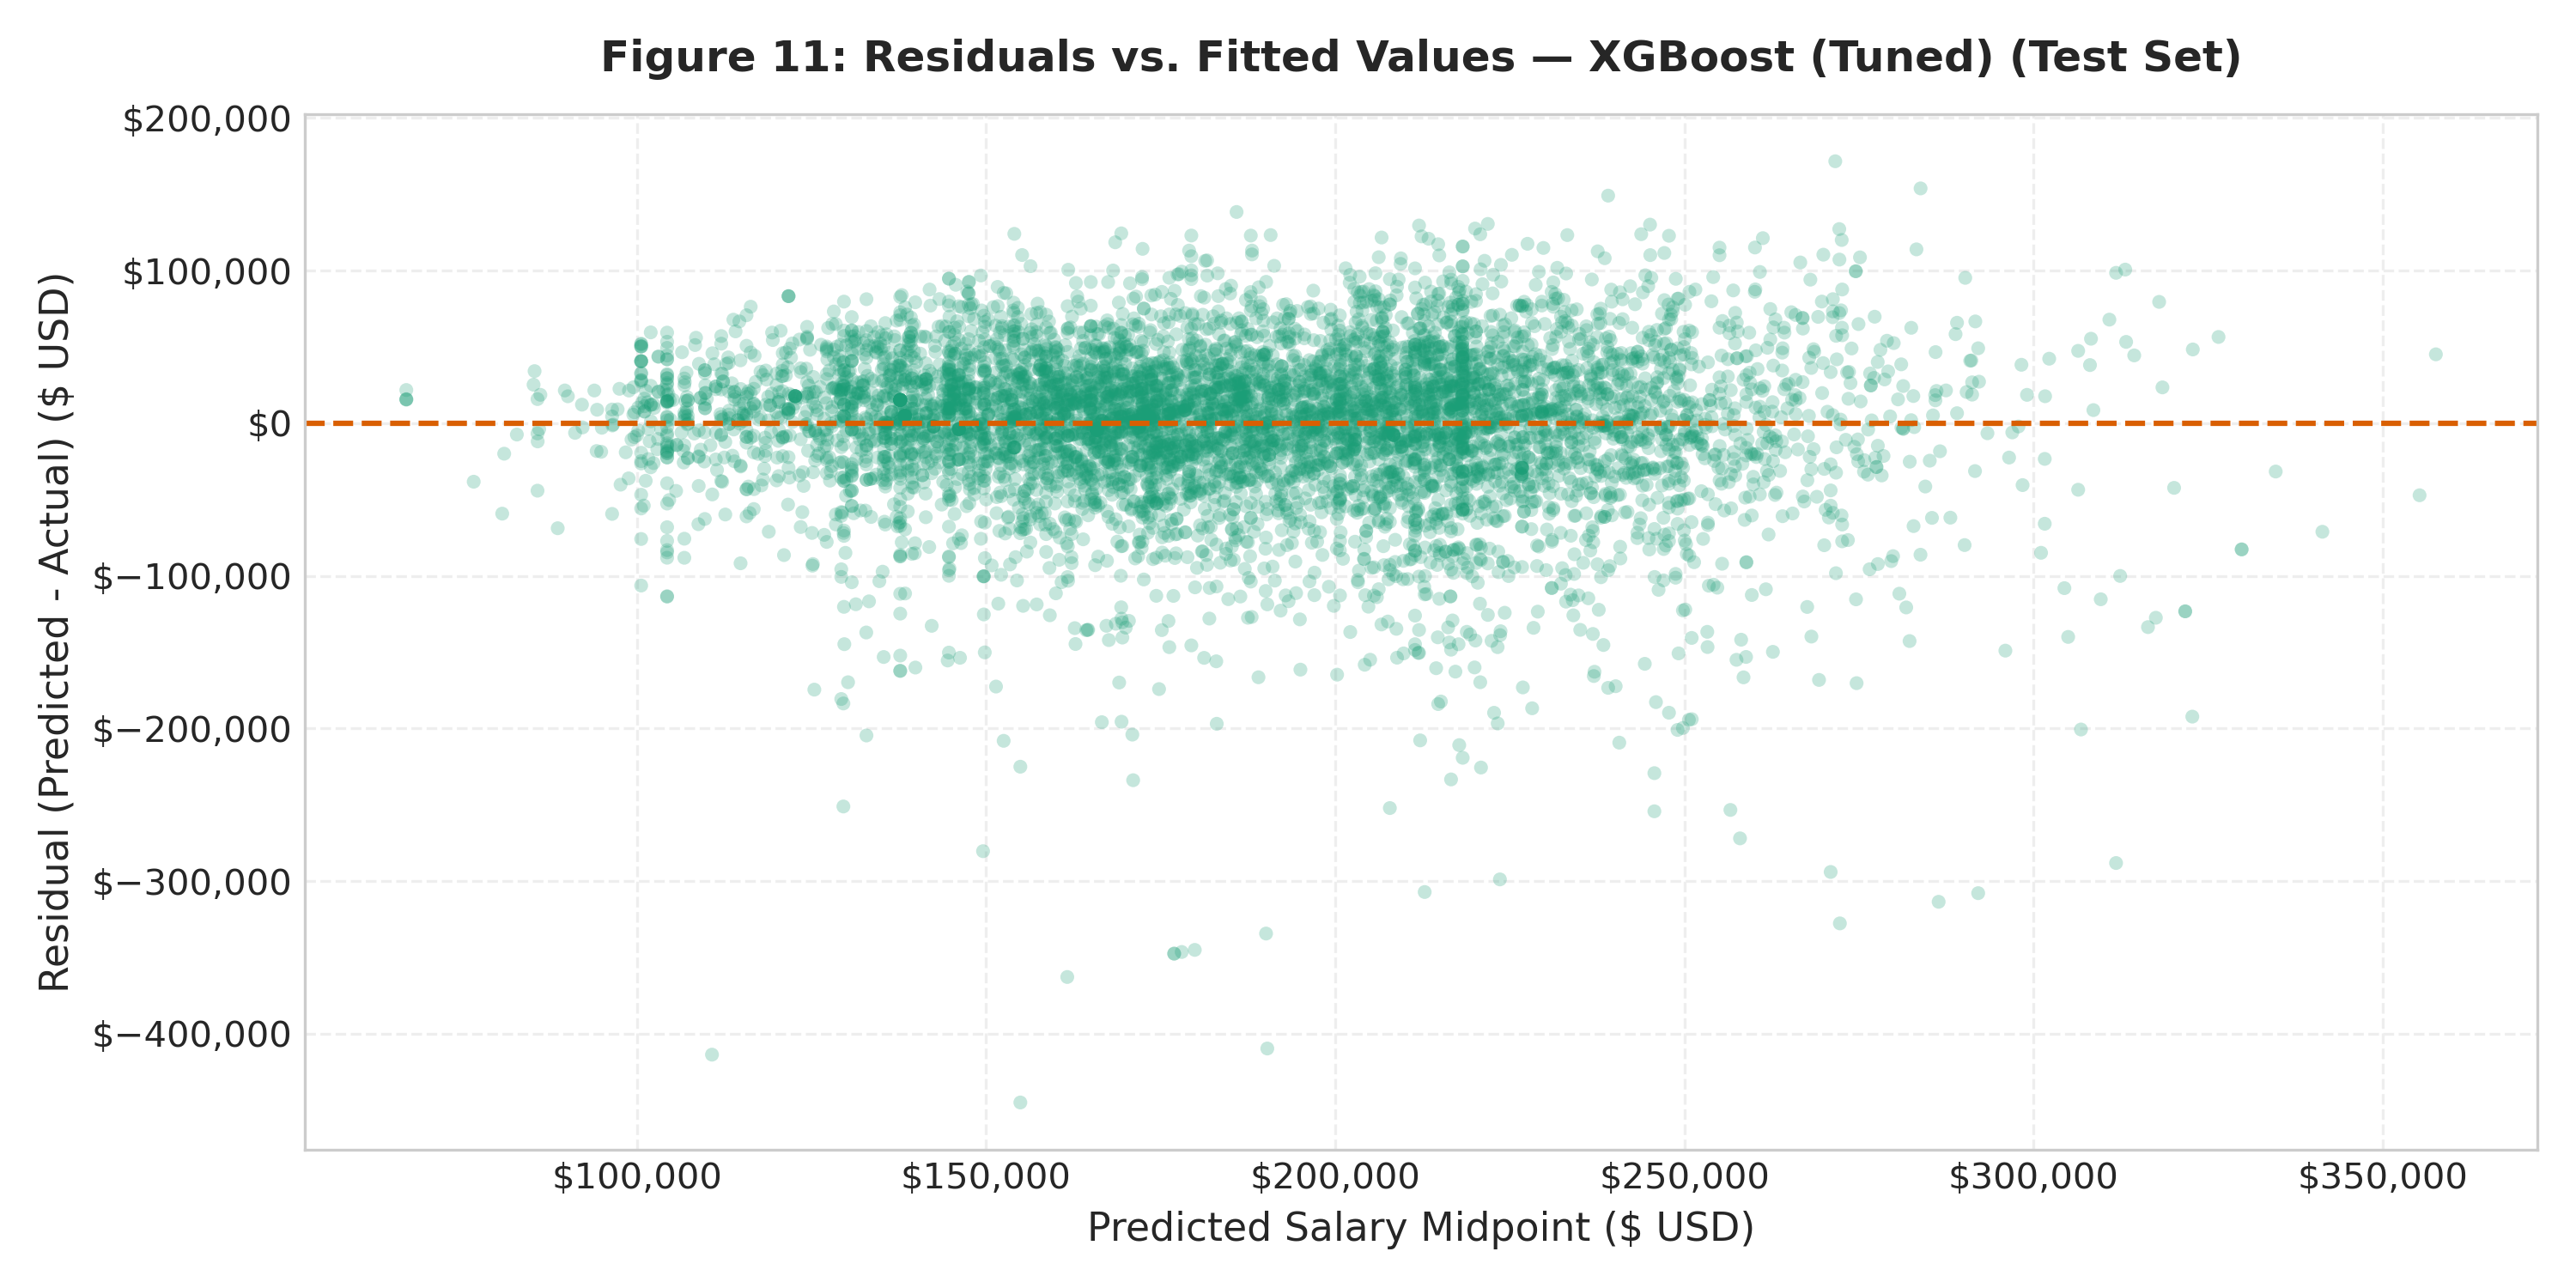

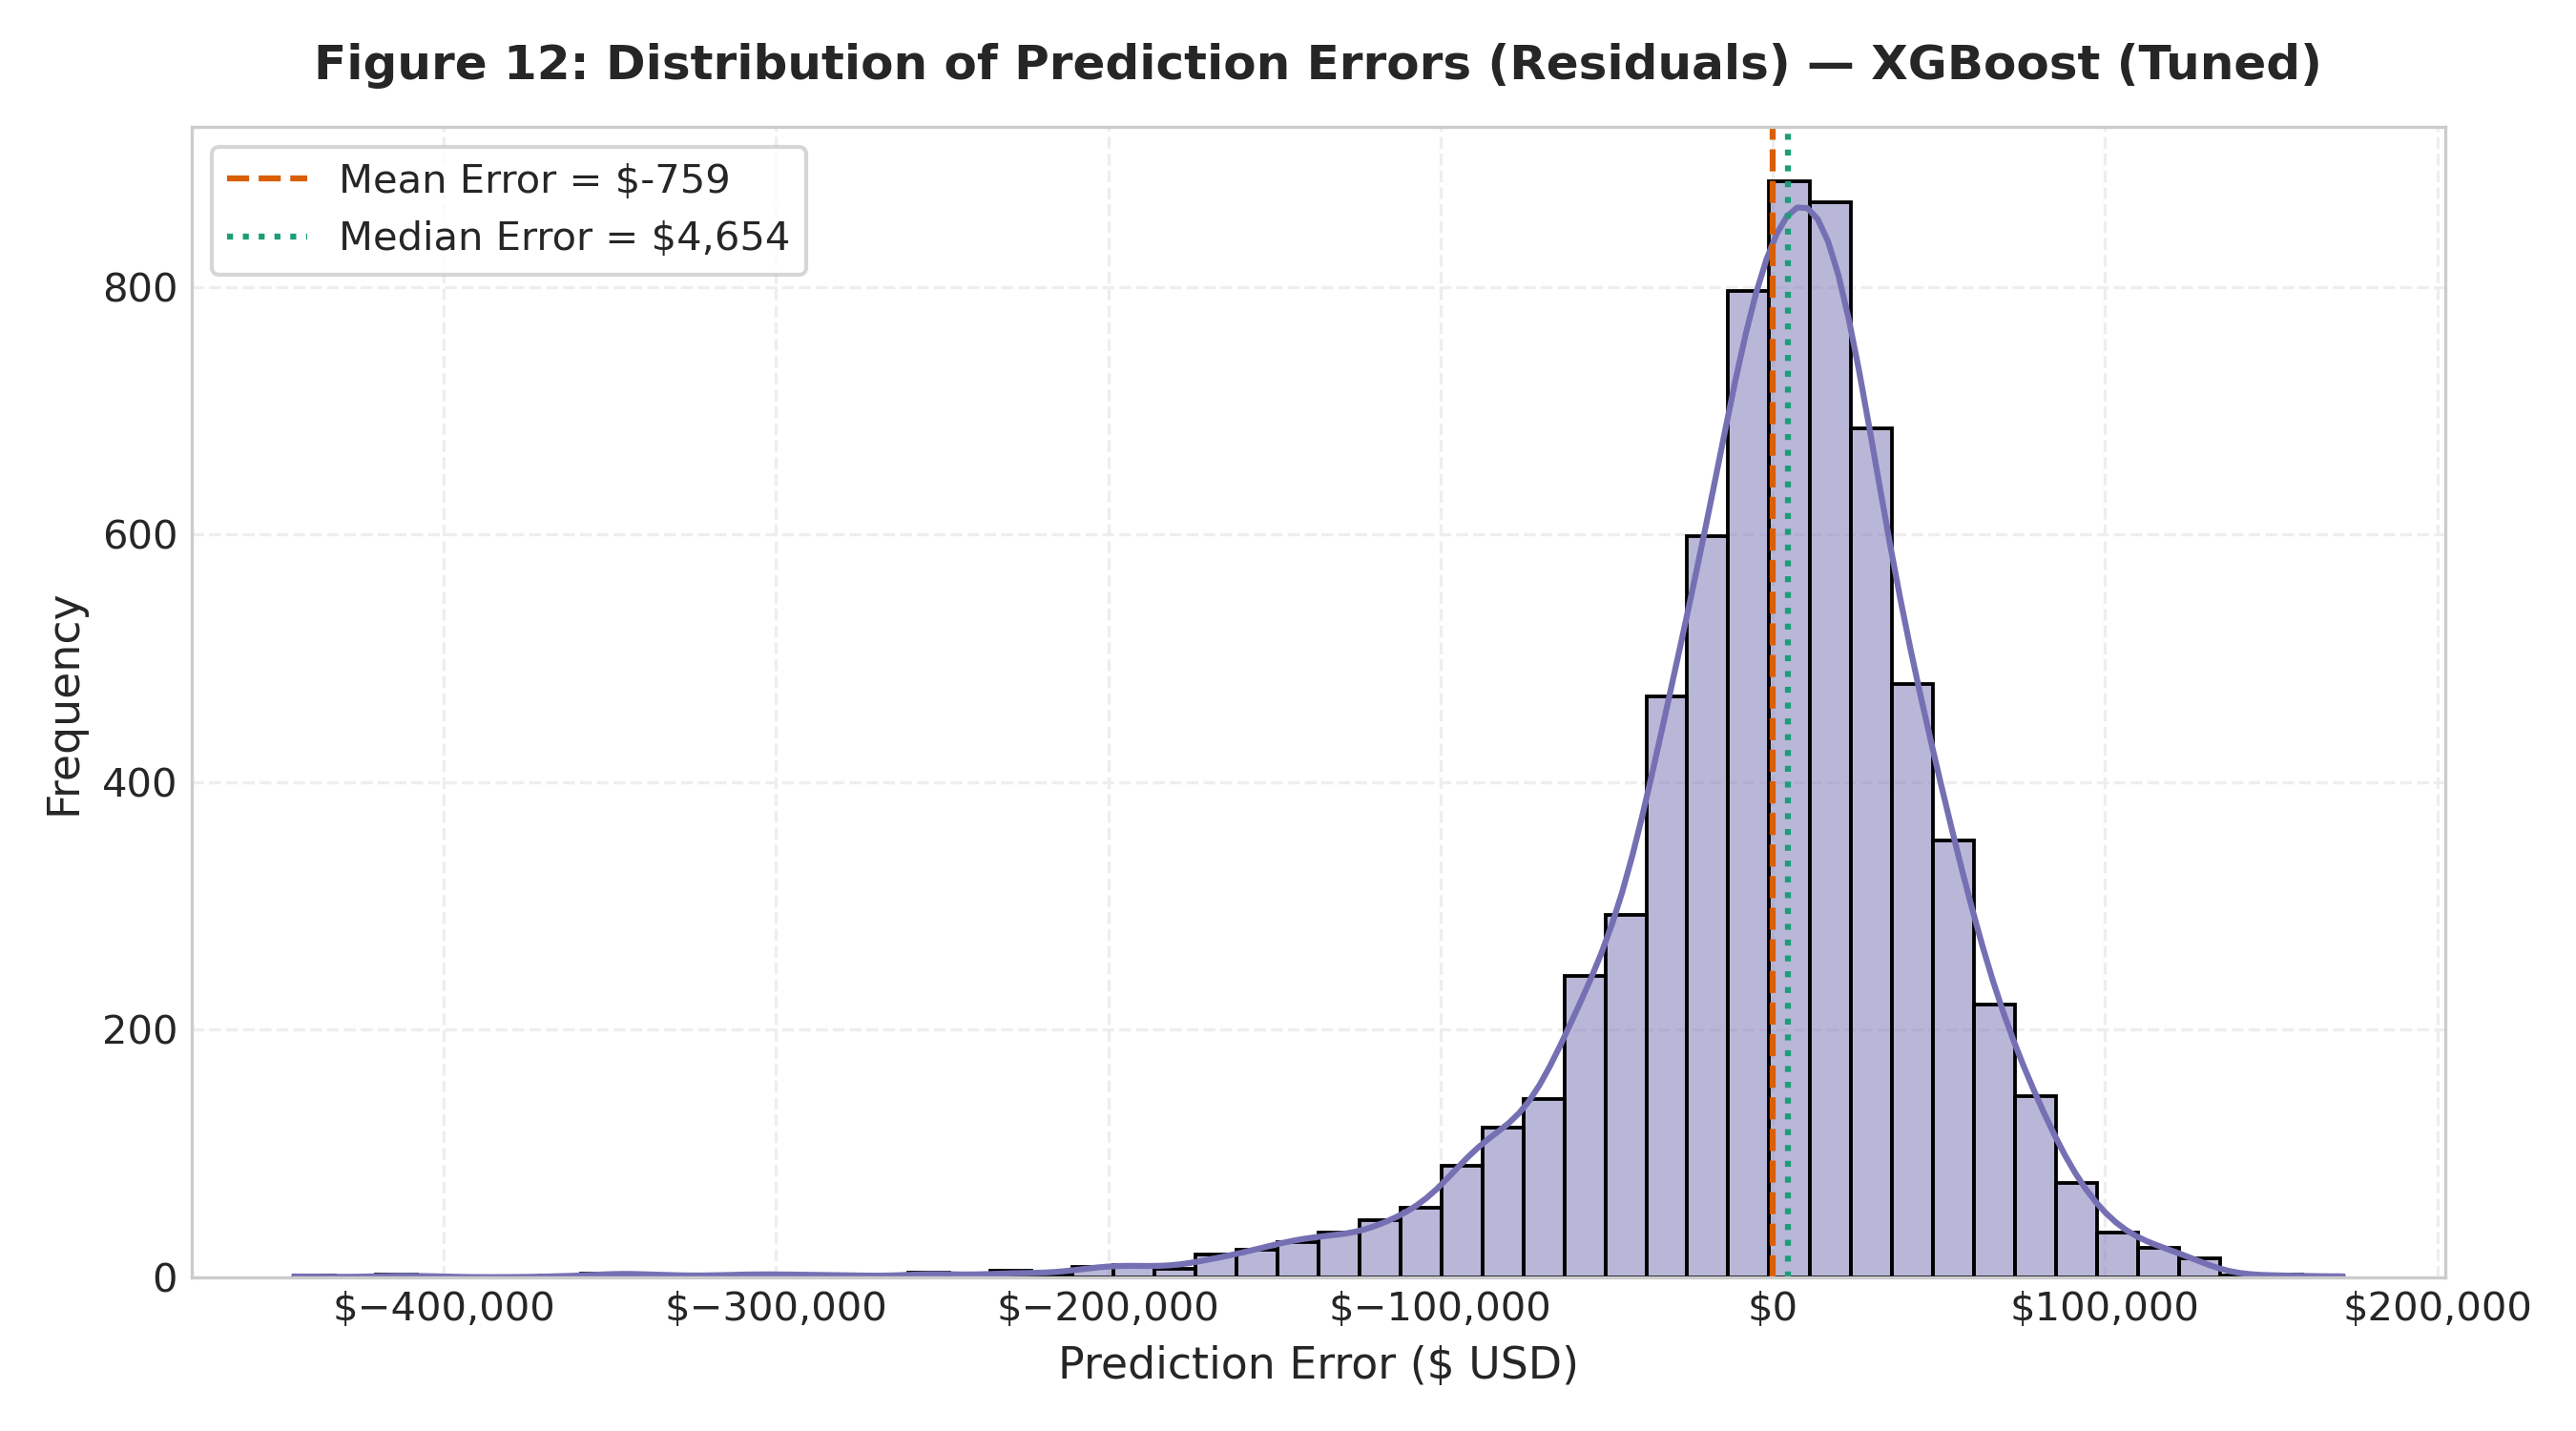

In [19]:
fig_path_pva = os.path.join(FIGURES_DIR, "10_predicted_vs_actual.png")
fig_path_rvp = os.path.join(FIGURES_DIR, "11_residual_vs_predicted.png")
fig_path_rd = os.path.join(FIGURES_DIR, "12_residual_distribution.png")

from IPython.display import Image
if os.path.exists(fig_path_pva):
    display(Image(filename=fig_path_pva))
if os.path.exists(fig_path_rvp):
    display(Image(filename=fig_path_rvp))
if os.path.exists(fig_path_rd):
    display(Image(filename=fig_path_rd))


## 20. Feature Importance & Permutation Importance

,Feature,Permutation_Importance_Mean,Permutation_Importance_Std,Rank
0,seniority_Lead / Principal / Executive,8982.108968,128.520177,1
1,city_clean_San Francisco,2615.421645,132.689528,2
2,num_skills,1989.510756,27.686598,3
3,skill_machine_learning,1074.408297,25.515970,4
4,seniority_Senior,938.730365,63.102314,5
5,role_family_Software Engineer,764.324341,106.616742,6
6,role_family_Other Tech,666.471207,48.464154,7
7,skill_kubernetes,644.110805,38.240290,8
8,seniority_Junior / Entry,592.122497,37.513798,9
9,skill_gis,375.380623,34.159100,10


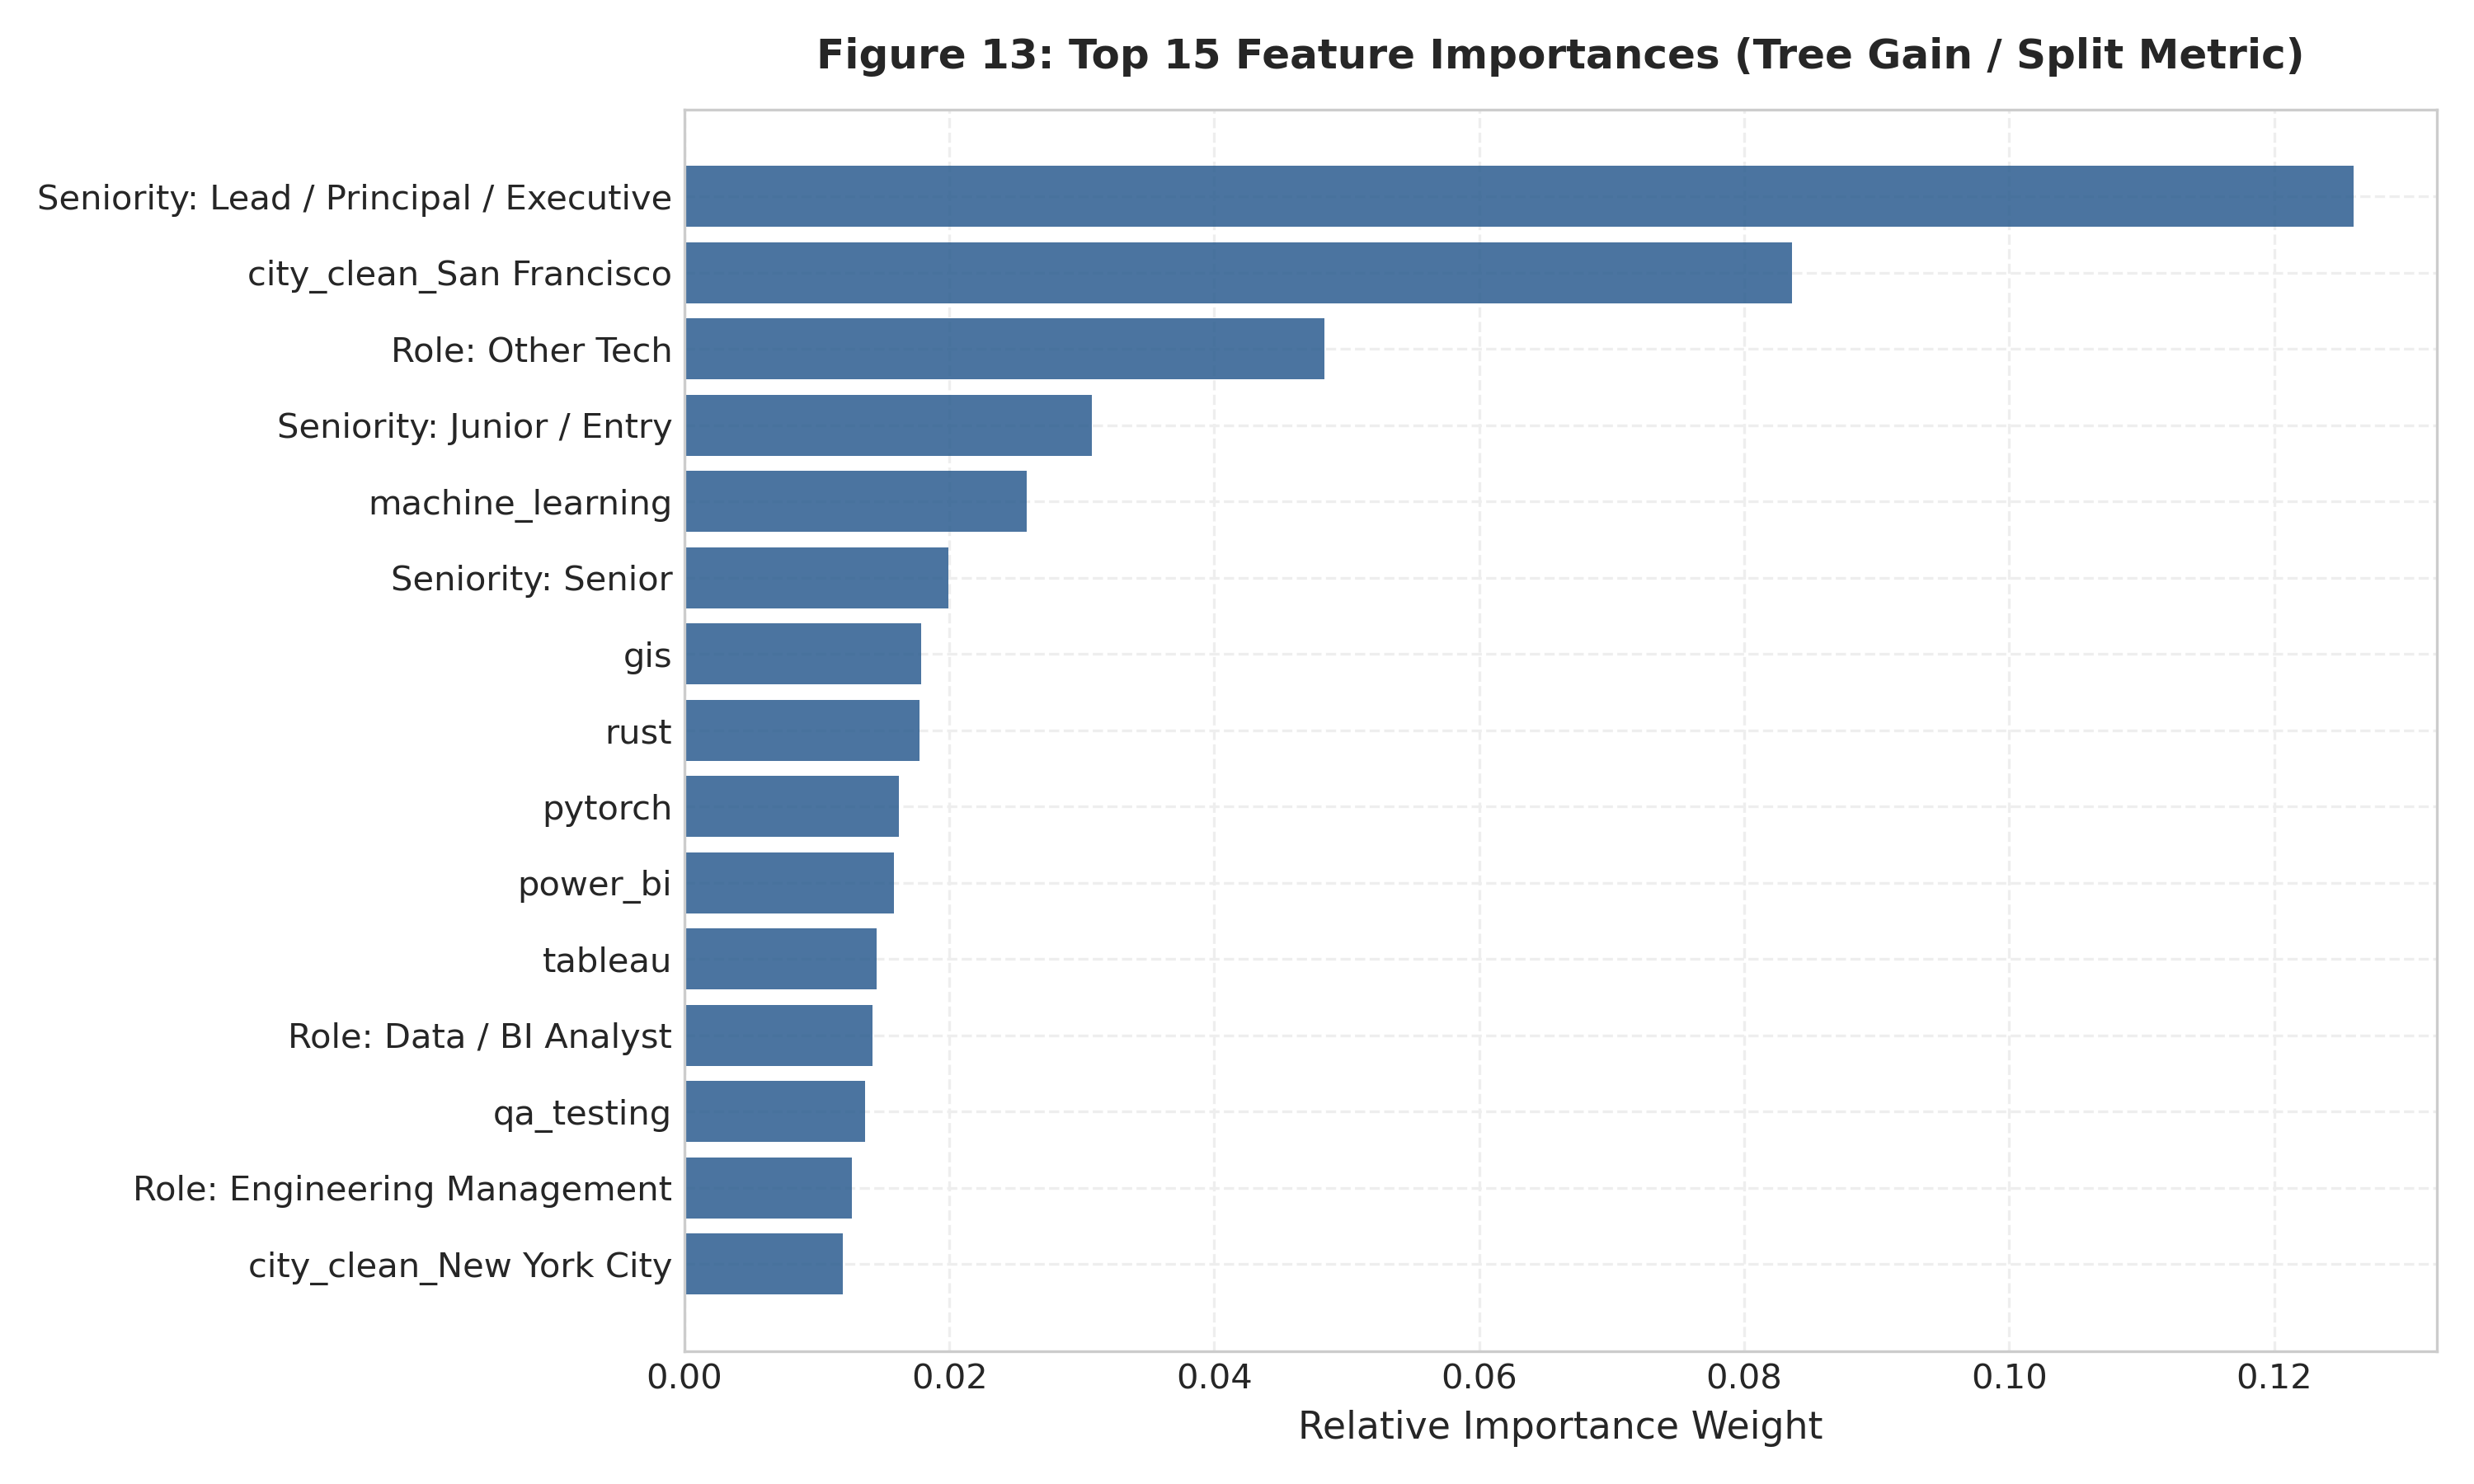

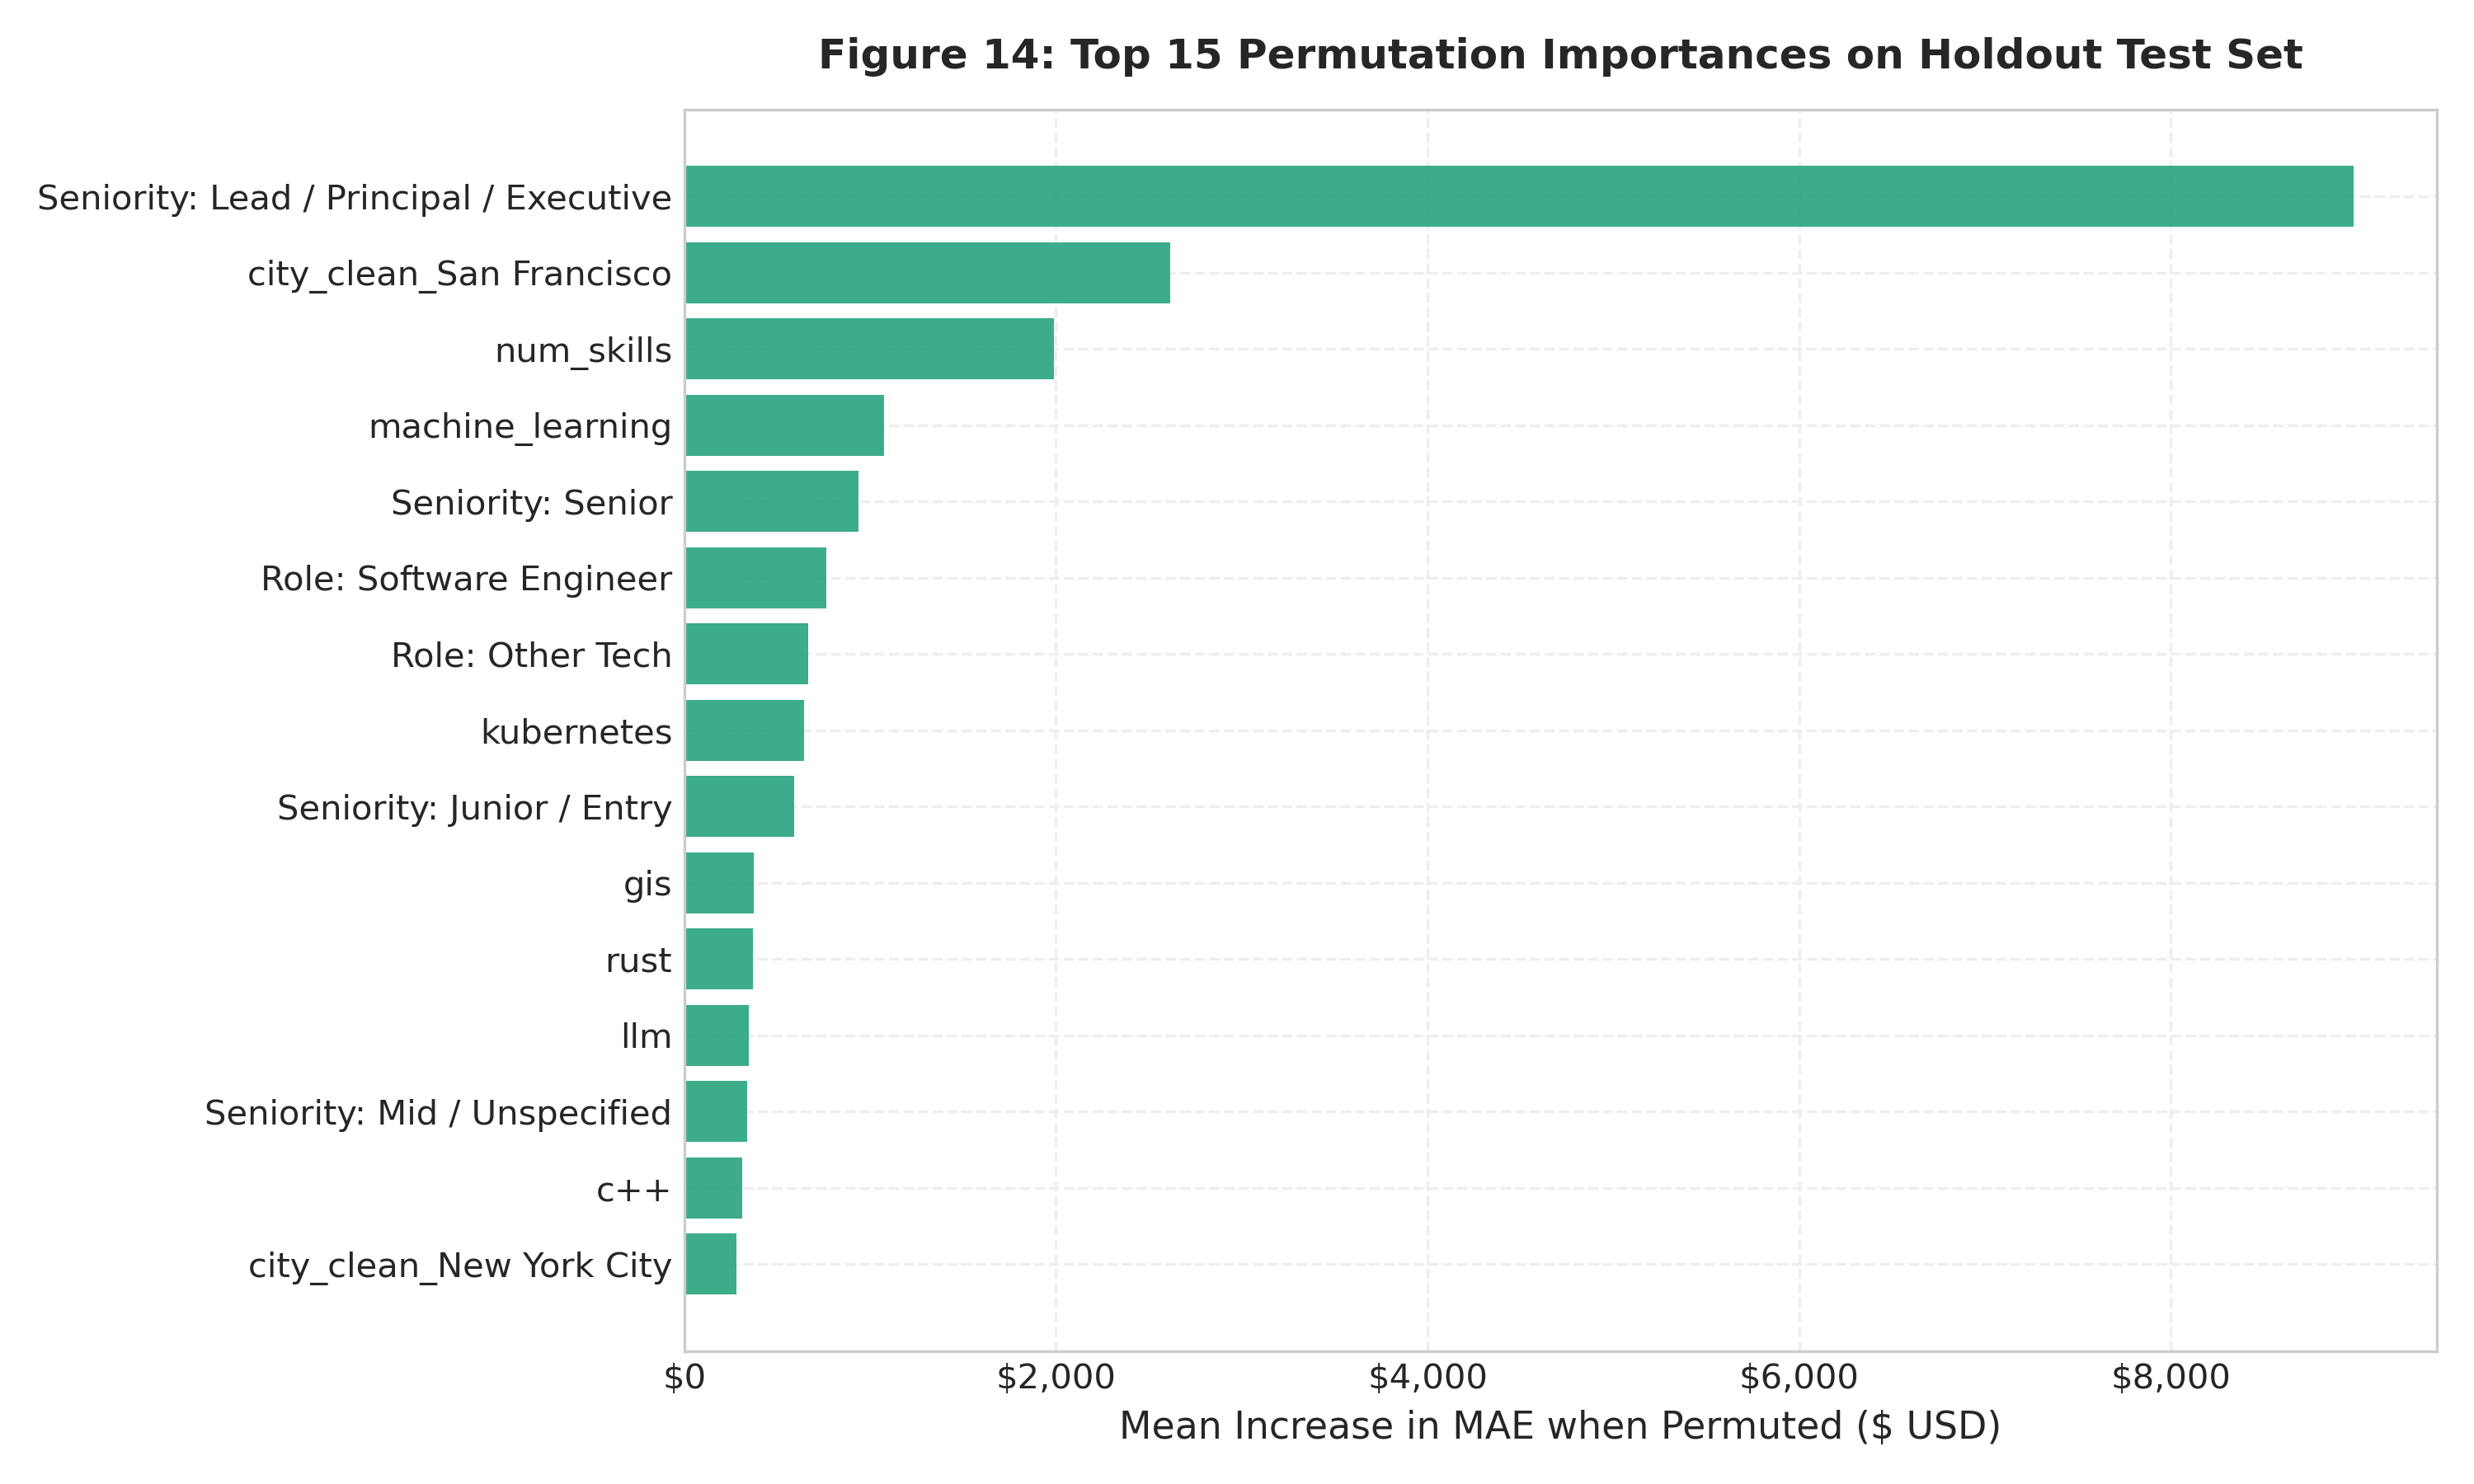

In [20]:
df_perm = pd.read_csv(os.path.join(TABLES_DIR, "phase5_permutation_importance.csv"))
display(df_perm.head(15).style.format({
    "Permutation_MAE_Mean": "${:,.0f}",
    "MAE_Increase_Mean": "${:,.0f}",
    "MAE_Increase_Std": "${:,.0f}",
}))

fig_path_fi = os.path.join(FIGURES_DIR, "13_feature_importance.png")
fig_path_pi = os.path.join(FIGURES_DIR, "14_permutation_importance.png")
if os.path.exists(fig_path_fi):
    display(Image(filename=fig_path_fi))
if os.path.exists(fig_path_pi):
    display(Image(filename=fig_path_pi))


## 21. Archetype-Level Error Analysis

,Archetype_ID,Archetype_Name,N,Median_Salary,MAE,RMSE,Median_AE,Mean_Bias,Relative_MAE_%,R2
0,0,FOUND_TECH (Foundational & Broad),2950,170000.000000,"$37,664","$51,966","$28,027",-1165.636109,22.155285,0.3930
1,1,DEVOPS_PLAT (DevOps & Cloud),441,195000.000000,"$32,745","$44,106","$24,377",1574.883557,16.792130,0.3799
2,2,WEB_FRONT (Frontend & Web),863,165650.000000,"$35,096","$49,908","$26,042",997.260294,21.187140,0.3849
3,3,CLOUD_ARCH (Multi-Cloud),813,220000.000000,"$46,098","$66,848","$33,333",-4448.302170,20.953797,0.2818
4,4,DATA_BI (Data & Analytics),831,170000.000000,"$31,985","$43,325","$23,319",793.129622,18.814775,0.4516
5,5,AI_ML (AI / Machine Learning),490,187250.000000,"$27,002","$36,135","$21,244",1797.297321,14.420068,0.4651
6,6,SYS_ENG (Systems & Backend),420,190000.000000,"$34,651","$47,761","$27,488",-2876.459188,18.237599,0.4797


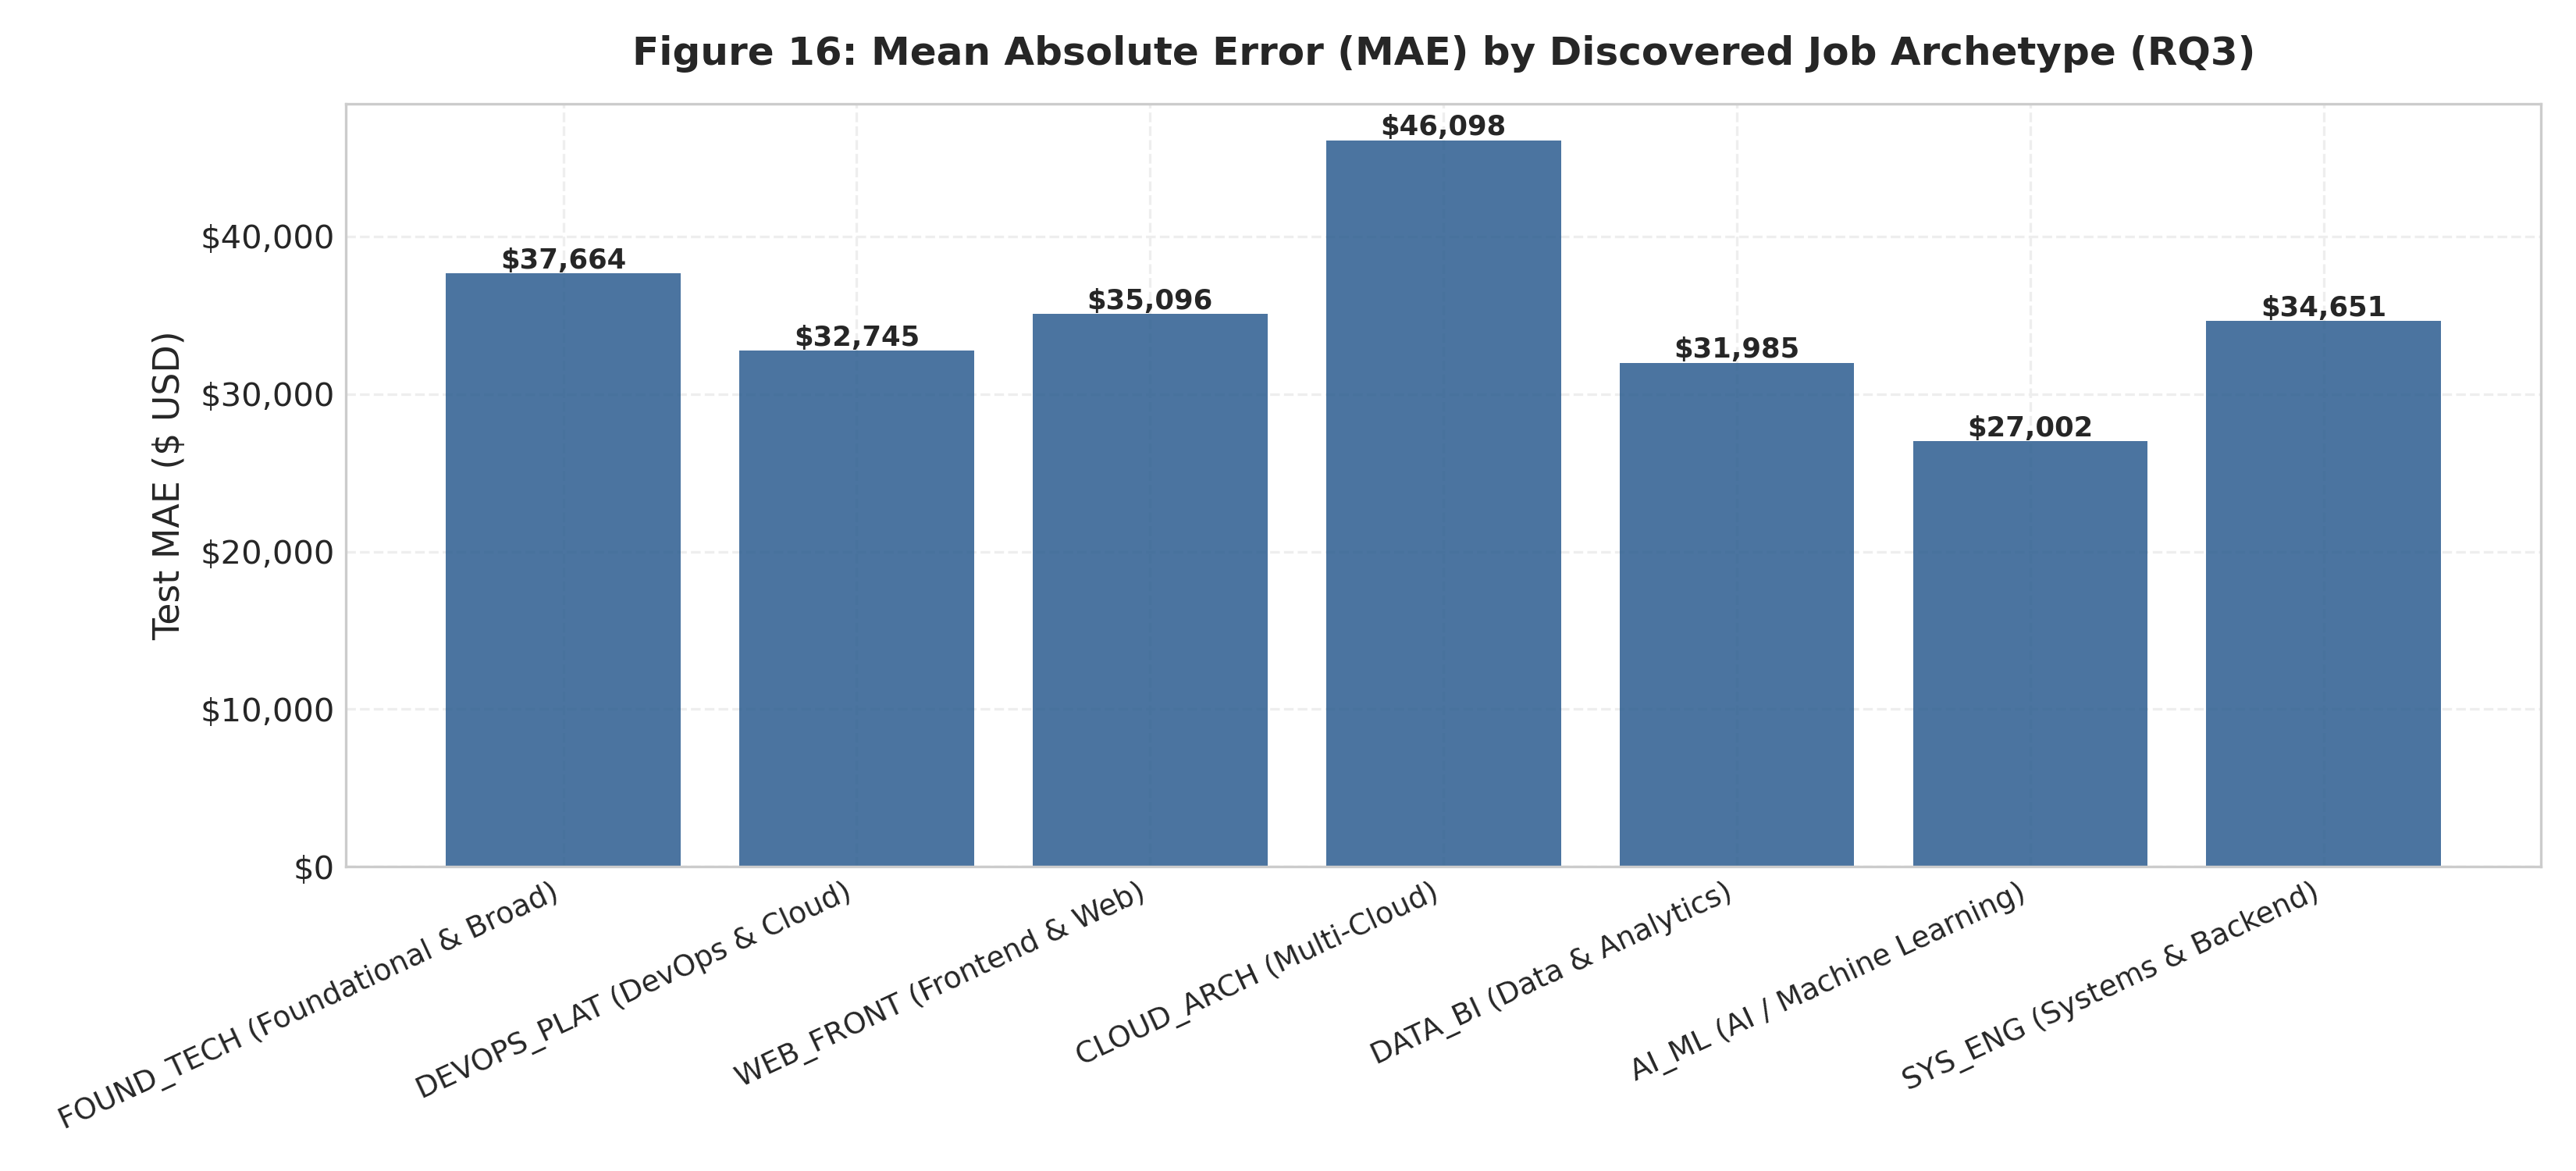

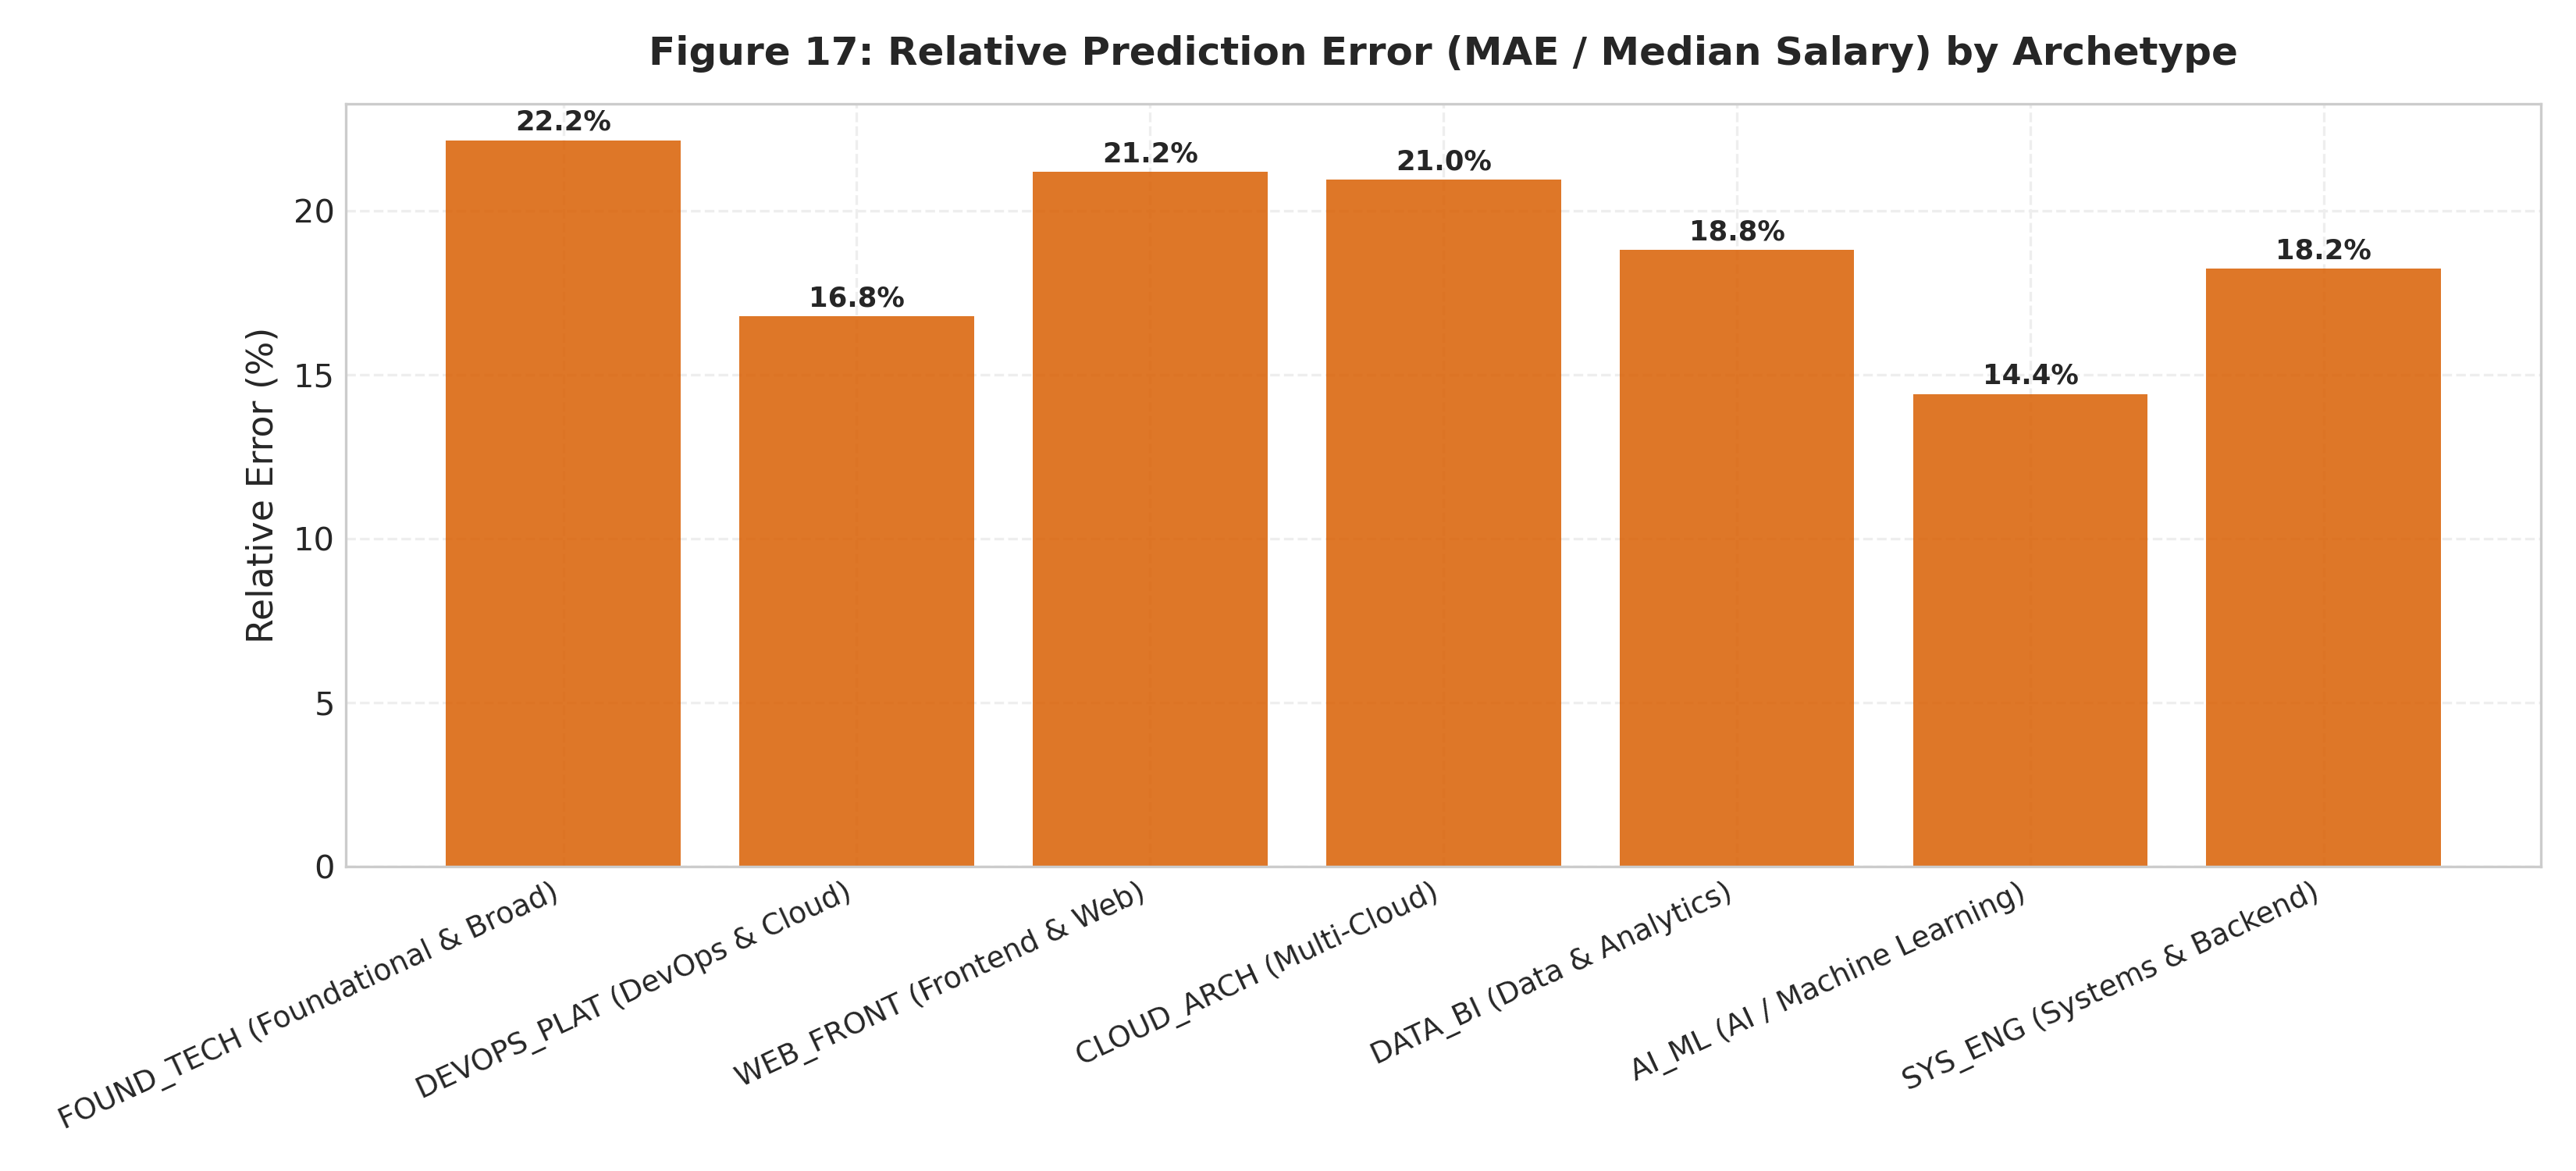

In [21]:
df_arch = pd.read_csv(os.path.join(TABLES_DIR, "phase5_archetype_errors.csv"))
display(df_arch.style.format({
    "N_Test": "{:,}",
    "MAE": "${:,.0f}",
    "RMSE": "${:,.0f}",
    "Median_AE": "${:,.0f}",
    "Mean_Error": "${:,.0f}",
    "Relative_MAE": "{:.2%}",
    "Median_Actual_Salary": "${:,.0f}",
    "R2": "{:.4f}",
}))

fig_path_am = os.path.join(FIGURES_DIR, "16_archetype_mae.png")
fig_path_ram = os.path.join(FIGURES_DIR, "17_archetype_relative_mae.png")
if os.path.exists(fig_path_am):
    display(Image(filename=fig_path_am))
if os.path.exists(fig_path_ram):
    display(Image(filename=fig_path_ram))


## 22. RQ1: Triangulated Skill-Salary Association Analysis
> **RQ1:** Which skills and skill combinations are most associated with higher salaries?

*Methodological Note:* Association $\neq$ causation. Evaluates predictive importance across tree split gain, test permutation importance, standardized Ridge coefficients, and observed profile differences.


In [22]:
df_rq1 = pd.read_csv(os.path.join(TABLES_DIR, "phase5_rq1_skill_associations.csv"))
display(df_rq1.head(15).style.format({
    "Tree_Gain_Importance": "{:.4f}",
    "Permutation_MAE_Increase": "${:,.0f}",
    "Ridge_Standardized_Coef": "${:,.0f}",
    "Composite_Predictive_Rank": "{:.2f}",
}))


,Skill,Feature_Tag,Tree_Importance,Tree_Rank,Permutation_Importance,Permutation_Rank,Ridge_Coefficient,Ridge_Direction,Ridge_Rank,Composite_Score,Composite_Rank
0,machine_learning,skill_machine_learning,0.025865,5,1074.408297,4,7541.044069,Positive,5,2.000000,1
1,gis,skill_gis,0.017886,7,375.380623,10,-3332.966463,Negative,14,1.040892,2
2,rust,skill_rust,0.017748,8,370.598404,11,3559.342388,Positive,11,1.031092,3
3,pytorch,skill_pytorch,0.016184,9,273.224678,16,4551.292368,Positive,8,0.880014,4
4,kubernetes,skill_kubernetes,0.005862,46,644.110805,8,3202.688336,Positive,15,0.826142,5
5,power_bi,skill_power_bi,0.015813,10,191.799554,27,-2746.967195,Negative,17,0.789889,6
6,tableau,skill_tableau,0.014506,11,228.405027,22,-2013.767111,Negative,31,0.773413,7
7,qa_testing,skill_qa_testing,0.013650,13,229.019732,21,-3726.824593,Negative,10,0.740883,8
8,deep_learning,skill_deep_learning,0.011548,16,154.493066,32,2331.095359,Positive,26,0.590279,9
9,llm,skill_llm,0.006667,35,346.547030,12,2415.729054,Positive,25,0.580320,10


## 23. RQ3: Systematic Error Differences Across Archetypes
> **RQ3:** Does salary-prediction error differ across skill-based job archetypes?

*Statistical Finding:* Prediction-error distributions differ significantly across the identified archetypes (Kruskal-Wallis  = 88.10$,  = 7.53 \times 10^{-17}$,  < 0.001$).


KRUSKAL-WALLIS H-TEST ON ABSOLUTE PREDICTION ERRORS:
  H-Statistic: 88.0969
  p-value:     7.5256e-17
  Statistically Significant at alpha=0.05: True


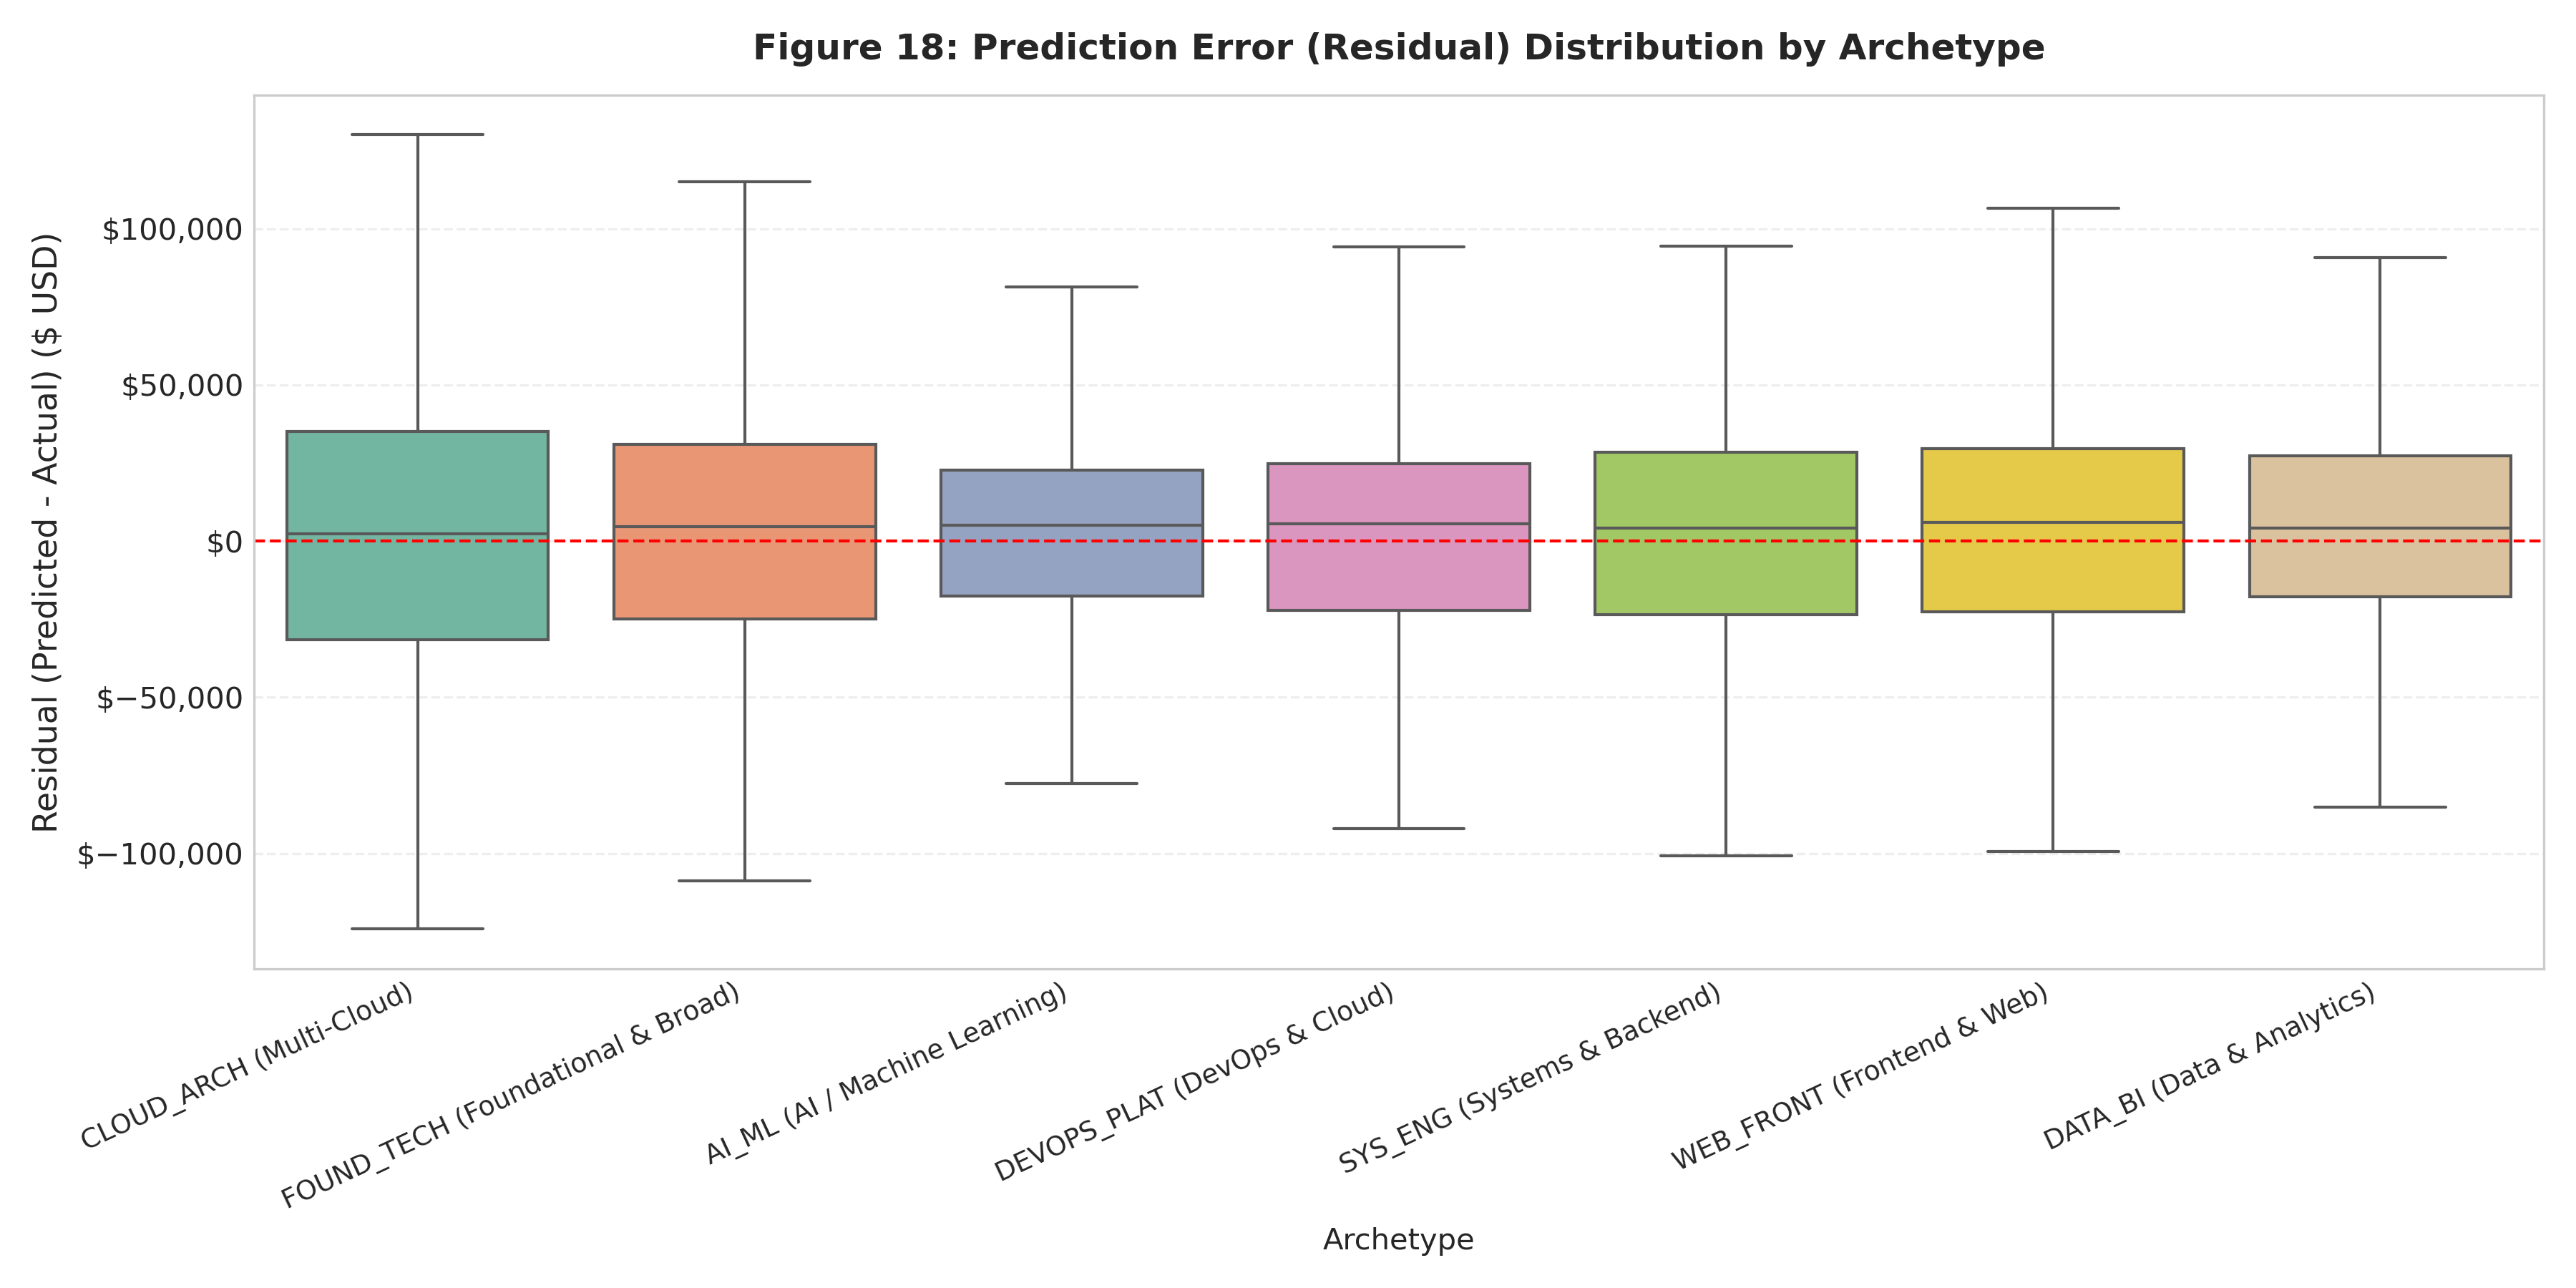

In [23]:
# Display statistical significance summary
with open(os.path.join(MODELS_DIR, "feature_metadata.json")) as f:
    meta = json.load(f)

kw = meta["kruskal_wallis"]
print("=" * 60)
print("KRUSKAL-WALLIS H-TEST ON ABSOLUTE PREDICTION ERRORS:")
print(f"  H-Statistic: {kw['kruskal_wallis_stat']:.4f}")
print(f"  p-value:     {kw['kruskal_wallis_pval']:.4e}")
print(f"  Statistically Significant at alpha=0.05: {kw['is_significant_005']}")
print("=" * 60)

fig_path_ard = os.path.join(FIGURES_DIR, "18_archetype_residual_distribution.png")
if os.path.exists(fig_path_ard):
    display(Image(filename=fig_path_ard))


## 24. Conclusions & Next Steps
### Scientific Findings Summary:
1. **Salary Predictability:** Supervised gradient boosting predicts tech salaries with a holdout test MAE of **$\,381$** (.7\%$ typical percentage error) and an ^2$ of **.4233$**, outperforming naive median baselines by **.4\%$**. However, individual predictions can still deviate substantially from actual compensation (MAE $\approx \\text{k}$).
2. **Archetype Incremental Value:** **Feature Set C provides no practically meaningful improvement over Feature Set A** (Test MAE difference: $+\.20$, or .12\%$). Archetypes provide valuable descriptive taxonomy and market navigation frameworks, but explicit skills preserve the principal predictive signal captured by the supervised models.
3. **RQ1 Skill Associations:** Premium salaries are most strongly associated with deep learning (pytorch, deep_learning), modern AI (machine_learning), cloud containerization (kubernetes, ws), and systems languages (golang, c++), conditioned heavily on seniority and metropolitan market.
4. **RQ3 Archetype Errors:** Prediction-error distributions differ significantly across archetypes ( = 88.10$,  = 7.53 \times 10^{-17}$). AI_ML postings exhibit the lowest absolute MAE ($\,002$) and lowest relative error (.42\%$), while CLOUD_ARCH postings have the highest absolute MAE ($\,098$) consistent with elevated salary scale and dispersion. Generalist roles (FOUND_TECH) exhibit the highest relative error (.16\%$) consistent with role heterogeneity.

---
**PHASE 5 SCIENTIFICALLY AUDITED AND FROZEN FOR HUMAN REVIEW**
